# RTT-aware routing: detailed experimental results

This report accompanies the project README. It presents the complete comparison of
RTT-aware flowlet routing, CONGA, and per-flow ECMP on five-second CDF traffic at
10 Gb/s. It includes workload, delivery, mean and tail FCT, packet loss, queue drops,
and individual link utilization for every selected load.

The experiment has two leaf switches, two spines, and four servers per leaf.
The symmetric fabric uses 10 Gb/s links. The asymmetric fabric reduces the
Leaf 0–Spine 0 connection to 5 Gb/s. Each policy receives the same input trace at
a given load. Symmetric loads extend to 0.9; asymmetric loads extend to 0.7.

| Policy label | Path selection and flowlet timeout |
| --- | --- |
| ECMP | Stable per-flow hash baseline |
| CONGA | Congestion-feedback routing with a fixed 500-us flowlet timeout |
| Weighted RTT / fixed | RTT-weighted probabilistic selection, fixed 500-us timeout |
| Weighted RTT / adaptive | RTT-weighted probabilistic selection, RTT-derived timeout |
| Random-Two / adaptive | Sample two candidate paths and select the lower RTT, RTT-derived timeout |

With only two candidate paths, Random-Two's candidate set is particularly small;
this topology does not evaluate its sampling behavior in a large fabric.

The simulations were run on a personal Dell Vostro laptop with an Intel Core
i5-1235U and 16 GB RAM. Individual 10 Gb/s RTT simulations have taken more than
24 hours of wall-clock time. The figures measure simulated network time; laptop
runtime is not part of FCT.

## Opening and sharing this report

First run **compare_rtt_readme_cdf_10gbps_5s.ipynb**, then run all cells here.
This notebook reads the exported PNGs and CSV summaries. It does not need the raw
simulation outputs or rerun the statistical comparison.

Save this notebook after execution. The displayed PNGs are embedded in its
outputs, so a reader can view the saved report without rerunning the analysis.
To rerun it outside the simulator tree, copy an entire export snapshot beside the
notebook and set **SNAPSHOT_DIR** to that folder. Keep its CSVs, images, and manifest
together. The default reads the most recent successful export for **WORKLOAD**.

The following cells explain the definitions before showing results. Symmetric
results precede asymmetric results, and every exported figure is included.


In [1]:
from pathlib import Path
import csv
import hashlib
import json
import math
from collections import Counter
from html import escape
from IPython.display import HTML, Image, Markdown, display

WORKLOAD = "ENT"                         # Change to "DM" to read DM exports.
SNAPSHOT_DIR = None                      # Or Path("copied-snapshot-folder")
FIGURE_WIDTH = 1300

if WORKLOAD not in ("ENT", "DM"):
    raise ValueError('WORKLOAD must be "ENT" or "DM".')
if SNAPSHOT_DIR is None:
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd() / "8_hosts_v9(prob1)"]
    if (Path.cwd() / "figure_manifest.json").is_file():
        SNAPSHOT_DIR = Path.cwd()
    else:
        export_parent = next(
            (p / folder / WORKLOAD for p in candidates
             for folder in ("readme_figures/rtt_cdf_10gbps_5s",
                            "results/ent-10gbps/rtt-full")
             if (p / folder / WORKLOAD / "latest.json").is_file()),
            None,
        )
        if export_parent is None:
            raise FileNotFoundError("No successful export found. Run the export notebook first, "
                                    "or set SNAPSHOT_DIR to a copied snapshot.")
        pointer = json.loads((export_parent / "latest.json").read_text())
        SNAPSHOT_DIR = export_parent / pointer["snapshot"]
SNAPSHOT_DIR = Path(SNAPSHOT_DIR).resolve()


def asset_path(relative):
    """Resolve only assets inside the chosen export snapshot."""
    path = (SNAPSHOT_DIR / relative).resolve()
    if not path.is_relative_to(SNAPSHOT_DIR):
        raise ValueError(f"Asset is outside the snapshot: {relative}")
    return path


manifest = json.loads(asset_path("figure_manifest.json").read_text())
configuration = json.loads(asset_path("configuration.json").read_text())
if manifest.get("schema_version") != 1 or configuration.get("schema_version") != 1:
    raise ValueError("Unrecognized export schema.")
if manifest["workload"] != WORKLOAD or configuration["workload"] != WORKLOAD:
    raise ValueError("The snapshot workload differs from WORKLOAD.")
if not manifest["validation"]["all_input_flows_verified"]:
    raise ValueError("This export did not pass the full flow-validation gate.")

FIGURES = manifest["figures"]
DISPLAYED = set()
SCENARIOS = [s for s in ("sym", "asym") if s in configuration["scenarios"]]
if len({r["png"] for r in FIGURES}) != len(FIGURES):
    raise ValueError("Duplicate figures in the manifest.")
for item in FIGURES:
    path = asset_path(item["png"])
    if not path.is_file():
        raise FileNotFoundError(f"Missing exported figure: {item['png']}")
    if hashlib.sha256(path.read_bytes()).hexdigest() != item["png_sha256"]:
        raise ValueError(f"Figure differs from the indexed export: {item['png']}")


def read_table(name):
    with asset_path(name).open(newline="") as stream:
        return list(csv.DictReader(stream))


def show_table(rows, columns, limit=None):
    """Present the saved values without recalculating the simulation metrics."""
    rows = list(rows)
    if not rows:
        display(Markdown("No entries."))
        return
    def format_value(value):
        if isinstance(value, float):
            return f"{value:,.5g}" if math.isfinite(value) else "unavailable"
        return str(value)
    selected = rows if limit is None else rows[:limit]
    headings = "".join(f"<th>{escape(column)}</th>" for column in columns)
    body = "".join("<tr>" + "".join(
        f"<td>{escape(format_value(row.get(column, '')))}</td>" for column in columns
    ) + "</tr>" for row in selected)
    display(HTML("<div style='overflow-x:auto'><table><thead><tr>" + headings +
                 "</tr></thead><tbody>" + body + "</tbody></table></div>"))
    if limit is not None and len(rows) > limit:
        print(f"Showing {limit} of {len(rows)} rows; the export CSV contains every row.")


def show_figure(item, heading_level=3):
    context = item["scenario"].upper()
    if item["load"] is not None:
        context += f" / target load {item['load'] / 10:g}"
    display(Markdown("#" * heading_level + f" {context}: {item['title']}\n\n" + item["caption"]))
    display(Image(data=asset_path(item["png"]).read_bytes(), format="png", width=FIGURE_WIDTH))
    DISPLAYED.add(item["png"])


def show_kinds(scenario, kinds):
    for kind in kinds:
        for item in FIGURES:
            if item["scenario"] == scenario and item["kind"] == kind:
                show_figure(item)


def show_loads(scenario):
    items = [r for r in FIGURES if r["scenario"] == scenario and r["load"] is not None]
    if not items:
        display(Markdown("Per-load figures were not selected in this export."))
    order = {"fct_cdf": 0, "fct_tail": 1, "uplink_utilization": 2}
    for item in sorted(items, key=lambda r: (r["load"], order.get(r["kind"], 99))):
        show_figure(item)


runs = read_table("run_summary.csv")
cohorts = read_table("cohorts.csv")
metrics = read_table("fct_summary.csv")
issues = read_table("issues.csv")
workload_rows = read_table("workload_summary.csv")
display(Markdown(f"**Workload:** {WORKLOAD} · **Export:** {manifest['run_label_utc']} · "
                 f"**Runs:** {len(runs)} · **Figures:** {len(FIGURES)}"))


**Workload:** ENT · **Export:** 20261008T074640_547349Z · **Runs:** 80 · **Figures:** 65

## How to read the measurements

Application FCT begins at the trace's scheduled start and ends when the complete
requested payload reaches the receiver. It includes TCP connection setup and any
completion during drain. The launch window is five seconds; it is not a deadline
for all transfers to finish. The runners allow a further 30 seconds after the final
flow starts.

The size classes are **small <100 KiB**, **medium 100 KiB–<1 MiB**, and
**large >=1 MiB**. Each FCT comparison uses the same flow identities in every
policy. Before export, received payload must equal the requested size, and the
independent sink audit must agree. FlowMonitor byte totals include protocol
overhead and are used separately from payload validation.

Absolute FCT is in milliseconds. Overall normalized figures use CONGA as the
reference; normalized size-class figures use ECMP. A value of 0.8 means that
statistic is 20% lower than the reference. A value of 1.2 means it is 20% higher.
The statistic is a mean or a p99 as labeled: these are ratios of statistics,
not averages of per-flow speedups.

The sample p99 describes the slow end of the observed flow distribution. It is
not an error bar or a confidence interval. The experiment currently has one
trace and one routing run per case, so the figures do not establish run-to-run
variation or statistical significance.


## Workload and offered load

A heavy-tailed workload can contain many short transfers but carry most of its
bytes in a few large transfers. The flow-weighted and byte-weighted CDFs answer
different questions and should look different. Both below are measured from the
generated traces, rather than redrawn from the original input CDF points.

Target load is based on the healthy fabric's aggregate 40 Gb/s directed uplink
capacity. The same trace is used for the asymmetric fabric; its target label is
not recalculated against the reduced capacity. Realized payload arrival load
can differ from the target in a five-second sample.


load,flows,payload_GiB,realized_load,seed
0.1,1678,2.8634,0.12298,12446
0.2,3211,3.3557,0.14412,12447
0.3,4795,9.4049,0.40394,12448
0.4,6549,11.535,0.49541,12449
0.5,8057,12.286,0.52768,12450
0.6,9607,15.366,0.65995,12451
0.7,11459,17.868,0.76743,12452
0.8,13074,20.308,0.87223,12453
0.9,14826,22.036,0.94643,12454


### WORKLOAD: Input flow sizes and realized load

Left: an empirical flow-size CDF, where each requested flow has equal weight. Middle: the cumulative fraction of requested payload bytes in flows up to each size; large flows dominate this byte-weighted view. Right: realized payload arrival load versus the target. Both topologies reuse the same trace at a given load. The denominator is the healthy fabric's aggregate directed uplink capacity (40 Gb/s in this setup), including for asymmetric runs. Five-second sampling of a heavy-tailed distribution can give a realized load above or below its target. These curves describe the input traces, not routing performance.

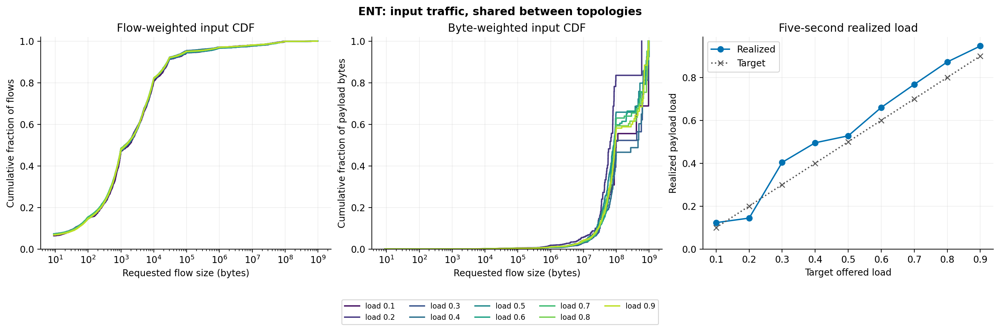

In [2]:
show_table(
    [dict(load=float(r["target_load"]), flows=int(r["input_flows"]),
          payload_GiB=int(r["requested_bytes"]) / 1024**3,
          realized_load=float(r["realized_load"]), seed=r["traffic_seed"])
     for r in workload_rows],
    ["load", "flows", "payload_GiB", "realized_load", "seed"],
)
show_kinds("workload", ["input_workload"])


## Coverage, delivery, and export findings

FCT can look artificially good if a slow flow never finishes and disappears from
the average. The exporter therefore refuses to publish performance figures
unless every selected run verifies every requested flow. The counts below make
that check visible. Flow records are counted separately per policy and topology,
so this total is not a count of distinct transfers in the input trace.

A reporting issue can remain even when every flow is delivered correctly. In
particular, the RTT CSV's reduced-link utilization may use the nominal 10 Gb/s
denominator. The exported heatmaps calculate it from bytes using 5 Gb/s. Findings
are shown by category so this correction is not confused with a short flow.


topology,policy,loads,input_flow_records,verified_flow_records,undersized,oversized,flows_with_issues
sym,ECMP,"0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9",73256,73256,0,0,0
sym,CONGA,"0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9",73256,73256,0,0,0
sym,Weighted RTT / fixed,"0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9",73256,73256,0,0,0
sym,Weighted RTT / adaptive,"0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9",73256,73256,0,0,0
sym,Random-Two / adaptive,"0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9",73256,73256,0,0,0
asym,ECMP,"0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7",45356,45356,0,0,0
asym,CONGA,"0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7",45356,45356,0,0,0
asym,Weighted RTT / fixed,"0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7",45356,45356,0,0,0
asym,Weighted RTT / adaptive,"0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7",45356,45356,0,0,0
asym,Random-Two / adaptive,"0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7",45356,45356,0,0,0


scenario,load,input_flows,shared_flows,excluded_flows,status
sym,1,1678,1678,0,complete cohort
sym,2,3211,3211,0,complete cohort
sym,3,4795,4795,0,complete cohort
sym,4,6549,6549,0,complete cohort
sym,5,8057,8057,0,complete cohort
sym,6,9607,9607,0,complete cohort
sym,7,11459,11459,0,complete cohort
sym,8,13074,13074,0,complete cohort
sym,9,14826,14826,0,complete cohort
asym,1,1678,1678,0,complete cohort


### Recorded findings

category,count
utilization,21


scenario,load,algorithm,category,issue
asym,1,weighted_fixed,utilization,Leaf 0 -> Spine 0: CSV reports 18.11%; calculated 36.22% using 5 Gb/s and the configured window
asym,1,weighted_adaptive,utilization,Leaf 0 -> Spine 0: CSV reports 19.33%; calculated 38.65% using 5 Gb/s and the configured window
asym,1,random_two_adaptive,utilization,Leaf 0 -> Spine 0: CSV reports 18.74%; calculated 37.48% using 5 Gb/s and the configured window
asym,2,weighted_fixed,utilization,Leaf 0 -> Spine 0: CSV reports 7.79%; calculated 15.58% using 5 Gb/s and the configured window
asym,2,weighted_adaptive,utilization,Leaf 0 -> Spine 0: CSV reports 16.25%; calculated 32.5% using 5 Gb/s and the configured window
asym,2,random_two_adaptive,utilization,Leaf 0 -> Spine 0: CSV reports 3.29%; calculated 6.59% using 5 Gb/s and the configured window
asym,3,weighted_fixed,utilization,Leaf 0 -> Spine 0: CSV reports 15.73%; calculated 31.46% using 5 Gb/s and the configured window
asym,3,weighted_adaptive,utilization,Leaf 0 -> Spine 0: CSV reports 15.55%; calculated 31.11% using 5 Gb/s and the configured window
asym,3,random_two_adaptive,utilization,Leaf 0 -> Spine 0: CSV reports 11.51%; calculated 23.01% using 5 Gb/s and the configured window
asym,4,weighted_fixed,utilization,Leaf 0 -> Spine 0: CSV reports 30.2%; calculated 60.39% using 5 Gb/s and the configured window


### SYM: Application delivery and validation

All requested flows are counted. The panels show exact-size deliveries, missing application bytes, and flows with any validation finding. Unknown receive counts are unavailable rather than zero. The figure gate also requires every independent sink audit and flow match to pass. The last two axes use a linear region around zero, followed by logarithmic scaling.

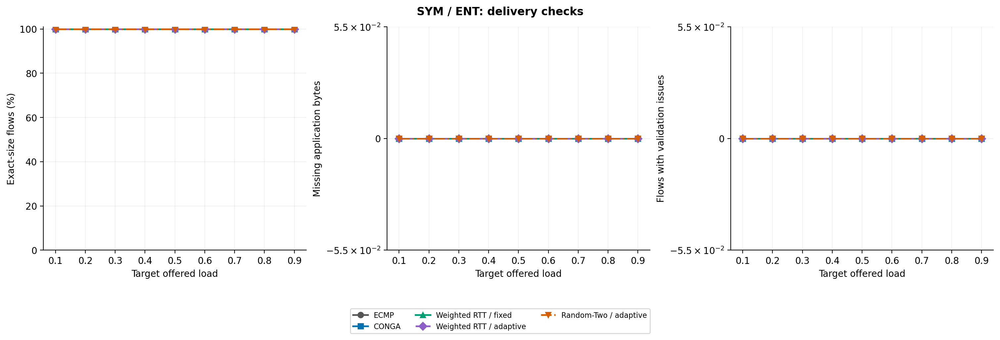

### ASYM: Application delivery and validation

All requested flows are counted. The panels show exact-size deliveries, missing application bytes, and flows with any validation finding. Unknown receive counts are unavailable rather than zero. The figure gate also requires every independent sink audit and flow match to pass. The last two axes use a linear region around zero, followed by logarithmic scaling.

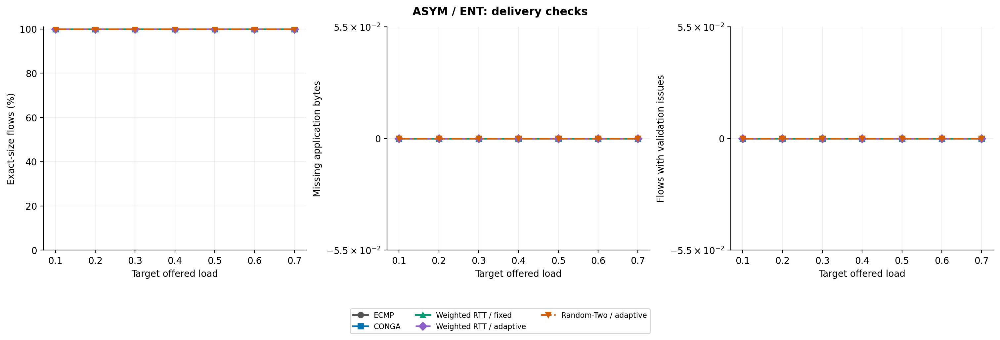

In [3]:
coverage = []
for scenario in SCENARIOS:
    for algorithm in configuration["algorithms"]:
        selected = [r for r in runs if r["scenario"] == scenario and r["algorithm"] == algorithm]
        coverage.append(dict(
            topology=scenario, policy=configuration["policies"][algorithm]["label"],
            loads=", ".join(f"{int(r['load']) / 10:g}" for r in selected),
            input_flow_records=sum(int(r["input_flows"]) for r in selected),
            verified_flow_records=sum(int(r["verified_flows"]) for r in selected),
            undersized=sum(int(r["undersized_flows"]) for r in selected),
            oversized=sum(int(r["oversized_flows"]) for r in selected),
            flows_with_issues=sum(int(r["flows_with_issues"]) for r in selected),
        ))
show_table(coverage, ["topology", "policy", "loads", "input_flow_records",
                      "verified_flow_records", "undersized", "oversized", "flows_with_issues"])
show_table(cohorts, ["scenario", "load", "input_flows", "shared_flows", "excluded_flows", "status"])
if issues:
    display(Markdown("### Recorded findings"))
    show_table([dict(category=k, count=v) for k, v in Counter(r["category"] for r in issues).items()],
               ["category", "count"])
    show_table(issues, ["scenario", "load", "algorithm", "category", "issue"], limit=40)
else:
    display(Markdown("No findings were recorded in issues.csv."))
for scenario in SCENARIOS:
    show_kinds(scenario, ["payload_delivery_vs_load"])


## Symmetric fabric: performance across loads

Start with the overall mean, then inspect the size-class and tail plots. An
overall average can hide a policy helping short flows while delaying large ones.
The normalized plots make relative differences easier to see when absolute FCT
spans several orders of magnitude.

Packet-loss and queue-drop figures follow the FCT panels. A shared zero line
means the counters coincide; it does not mean an algorithm was omitted. FCT
differences can exist without recorded drops because paths can have different
queueing delays.


### SYM: Overall mean application FCT

The left panel shows the arithmetic mean over all input flows, in milliseconds on a logarithmic axis. The right divides each mean by CONGA's mean for the same flows; lower is better and one equals CONGA. Small and large transfers each contribute one FCT value. The overall mean is not an average of the size-class means. Compare within a topology; asymmetric experiments have less capacity.

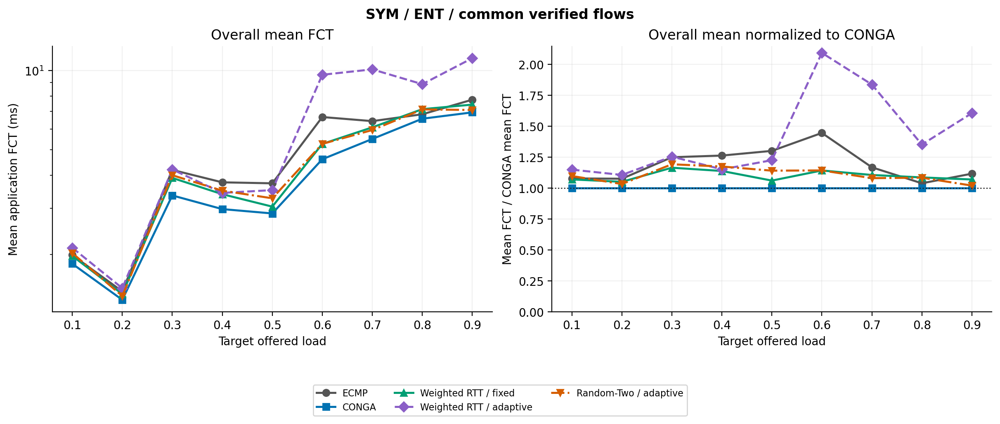

### SYM: Overall p99 application FCT

The left panel is the sample 99th percentile over all flow sizes. The right is the ratio of that percentile to CONGA's percentile for the same input-flow cohort. A larger mean improvement can coexist with a worse p99. These are quantiles of one simulation's flow population, not confidence intervals across repeated runs.

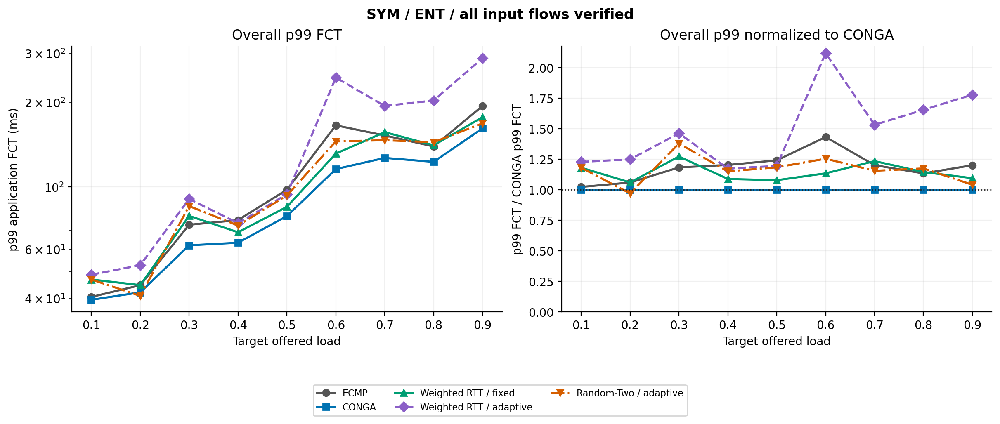

### SYM: Mean and p99 FCT by flow size

Columns split flows at 100 KiB and 1 MiB; rows show the arithmetic mean and sample p99. The vertical axes are logarithmic and may have different scales. Inspect large-flow behavior separately from small-flow latency. The fct_summary.csv file records the sample count for each class; a p99 from a small class depends on very few flows.

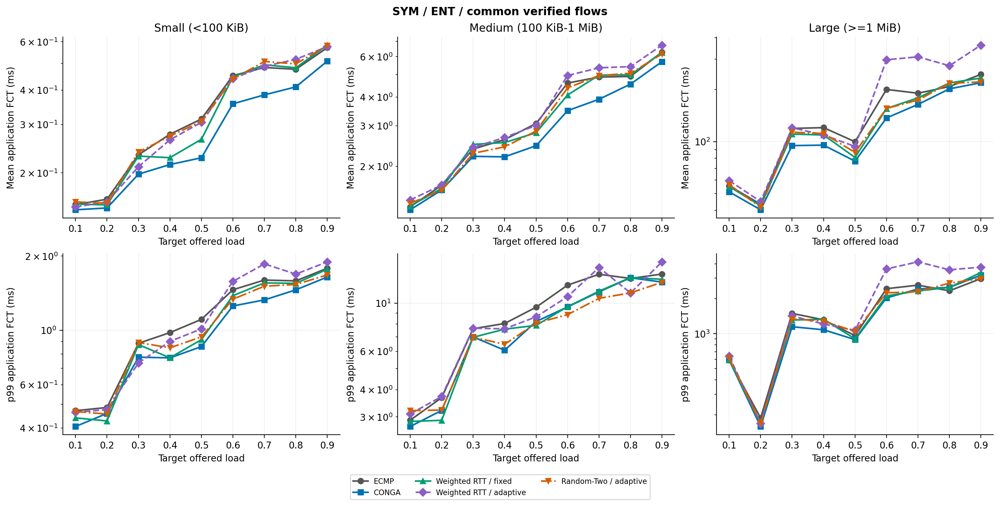

### SYM: Size-class mean FCT relative to ECMP

Each point is mean(policy FCT) / mean(ECMP FCT) in the same size class and matched cohort. Below one means a lower mean FCT than ECMP; above one means a higher mean. This is a ratio of means, not the mean of individual flow ratios. The denominator is ECMP, unlike the overall normalized panels.

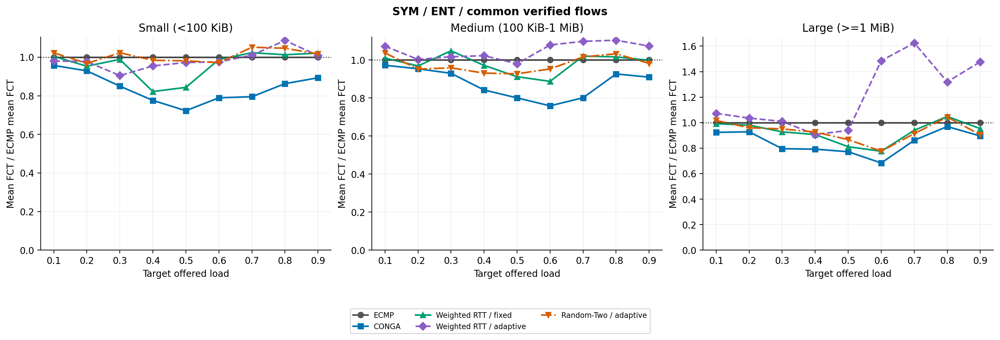

### SYM: Size-class p99 FCT relative to ECMP

Each point divides the policy's sample p99 by ECMP's sample p99 over the same size class and flow cohort. Below one means a lower tail percentile. A p99 ratio is not the 99th percentile of per-flow speedups, and it does not describe run-to-run uncertainty.

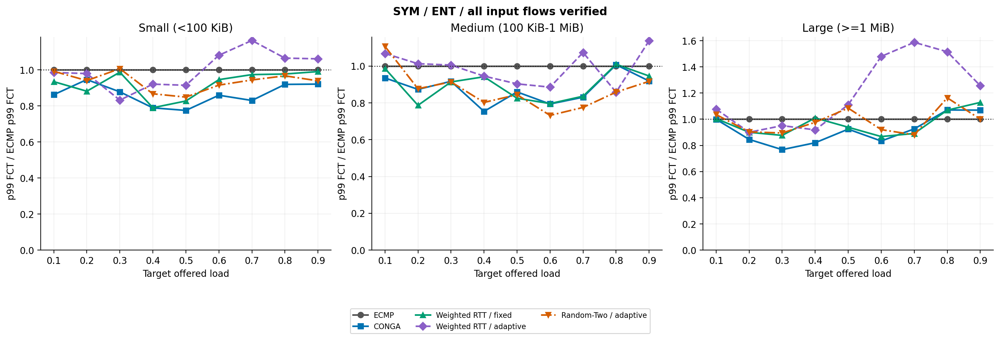

### SYM: Forward TCP packet loss

FlowMonitor lost packets divided by transmitted packets, multiplied by 100, for forward TCP connections matched uniquely to the input flows. This includes connection-control traffic on those connections; it is not a fraction of missing payload bytes or a count of all retransmissions. Zero means no recorded forward losses under this counter.

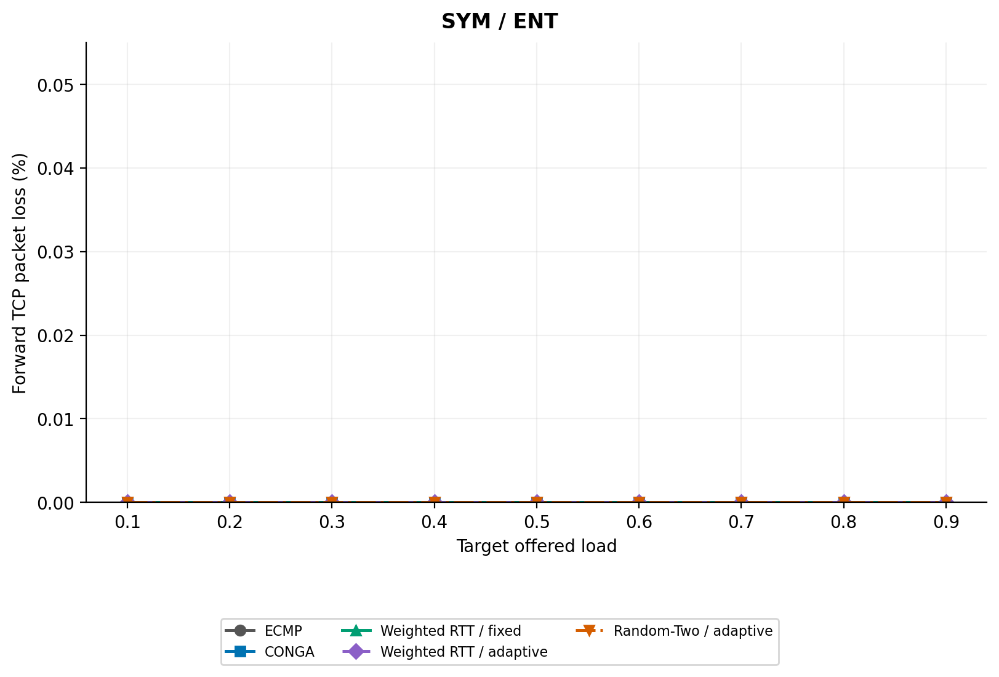

### SYM: Packet loss and queue drops

The panels show forward FlowMonitor loss, root queue-disc drops across all interfaces and directions, root drops per delivered MiB, and device-queue drops. These counters have different scopes and may refer to overlapping packet events; do not add them. Root FqCoDel drops may represent queue management, not merely a physically full device queue. Event-stage and reason tables are exported under each topology's summary folder. Coincident zero-valued curves can cover one another.

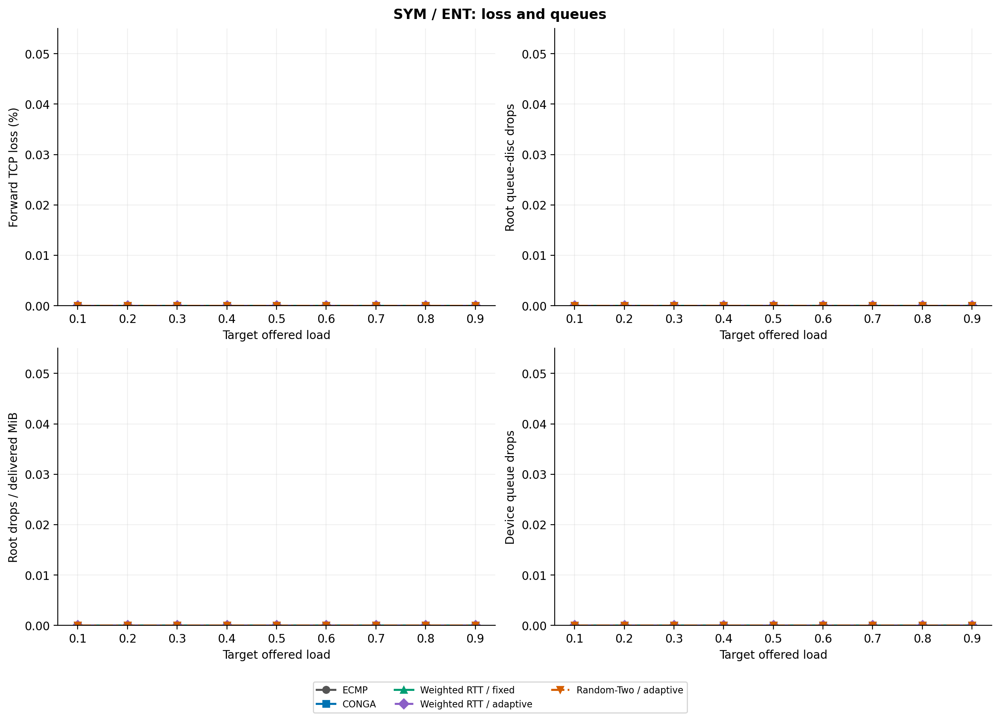

In [4]:
OVERVIEW_KINDS = [
    "overall_mean_fct_vs_load", "overall_p99_fct_vs_load", "fct_vs_load",
    "normalized_mean_fct_vs_load", "normalized_p99_fct_vs_load",
    "forward_packet_loss_vs_load", "packet_loss_and_queue_drops",
]
if "sym" in SCENARIOS:
    show_kinds("sym", OVERVIEW_KINDS)
else:
    display(Markdown("The selected snapshot does not include symmetric runs."))


## Symmetric fabric: distributions and link use at each load

For each load, the ordinary CDF shows the whole FCT distribution, the
complementary CDF exposes the tail, and the heatmap shows average directed
uplink utilization during the arrival window.

Each heatmap cell has its own link-capacity denominator. Percentages across
links do not sum to 100%. Averages over five seconds do not expose short-lived
hotspots, so a balanced-looking heatmap does not imply equal queueing delay.


### SYM / target load 0.1: Per-load FCT distribution

Within each size class, the vertical value is the fraction of verified completed flows with application FCT at or below the horizontal value. The horizontal scale is logarithmic; a curve further left reaches a given completion fraction sooner. Step shapes, especially for a small large-flow population, are expected. Each panel gives its number of flows per policy; no sizes are pooled across classes.

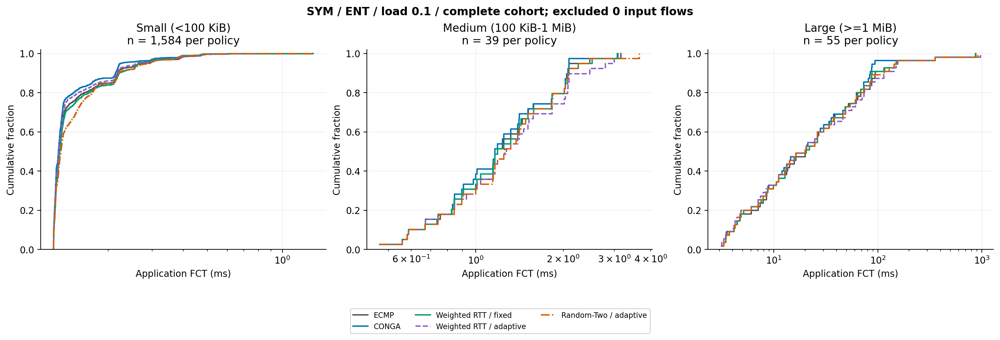

### SYM / target load 0.1: Per-load FCT tail

The complementary CDF shows the fraction with application FCT strictly greater than the horizontal value, using logarithmic axes. At a fixed threshold, lower means fewer flows exceed it. The dotted 0.01 reference marks a one-percent tail. Ties are counted together and the zero-probability endpoint is omitted; a curve ending before another is not an incomplete transfer. Sample counts are shown, and the ordinary CDF remains available alongside this view.

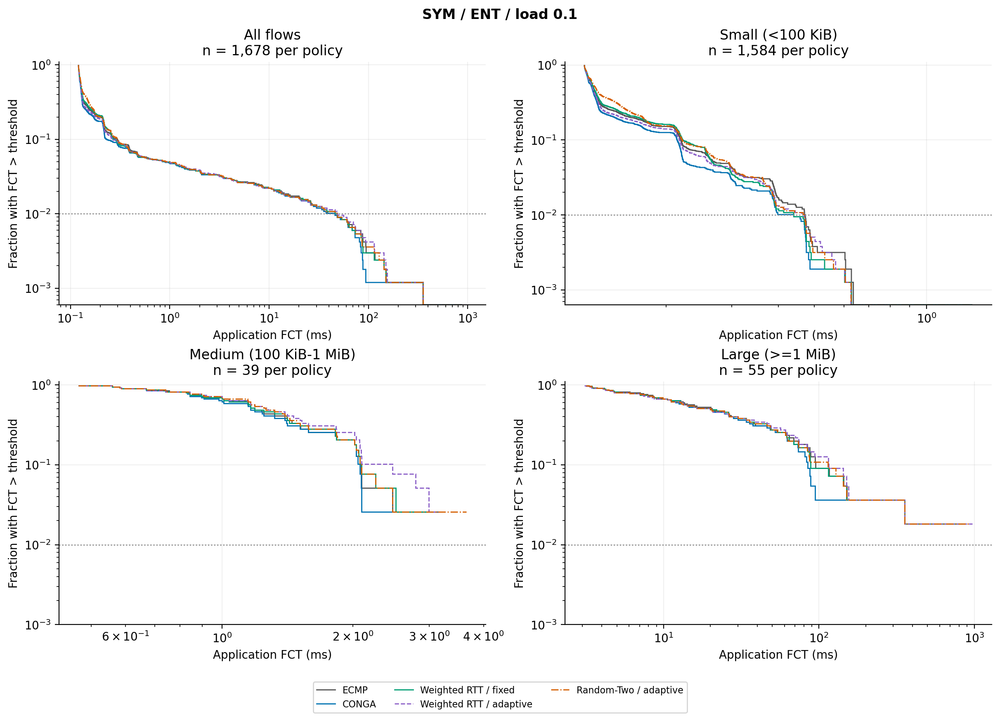

### SYM / target load 0.1: Per-load directed uplink utilization

Each cell is bytes transmitted on that leaf-to-spine link during 0–5 s, divided by that individual link's capacity over five seconds. Cells are not shares of a single total and do not sum to 100%. The reduced Leaf 0–Spine 0 link uses 5 Gb/s for asymmetric runs. Other links use 10 Gb/s. The same color scale is used across all exported heatmaps. Traffic during drain is excluded; these averages do not reveal instantaneous queueing or prove packet reordering.

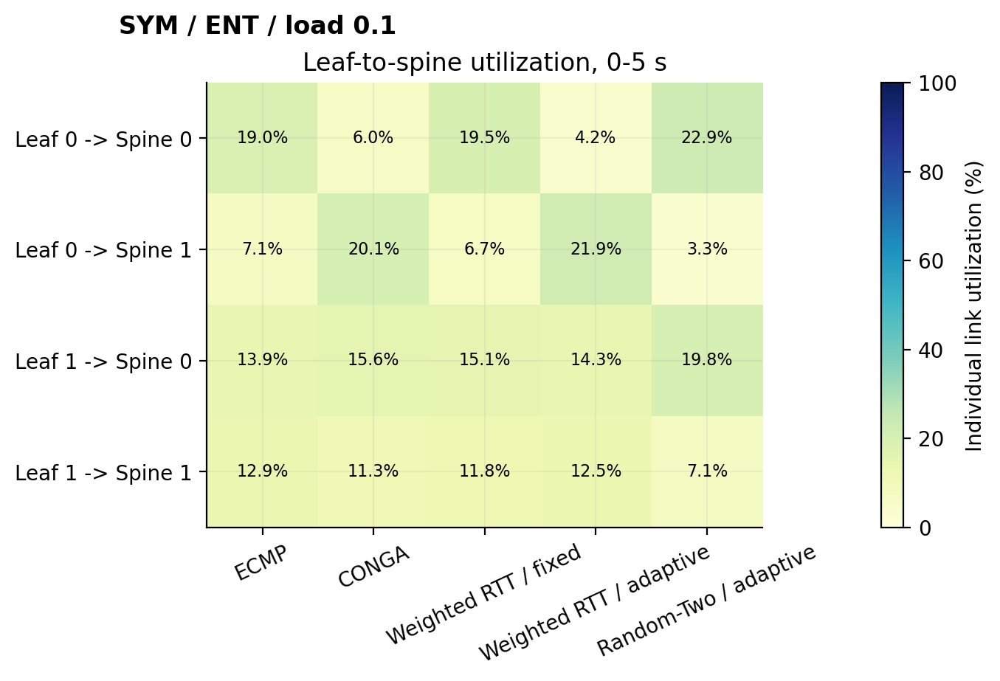

### SYM / target load 0.2: Per-load FCT distribution

Within each size class, the vertical value is the fraction of verified completed flows with application FCT at or below the horizontal value. The horizontal scale is logarithmic; a curve further left reaches a given completion fraction sooner. Step shapes, especially for a small large-flow population, are expected. Each panel gives its number of flows per policy; no sizes are pooled across classes.

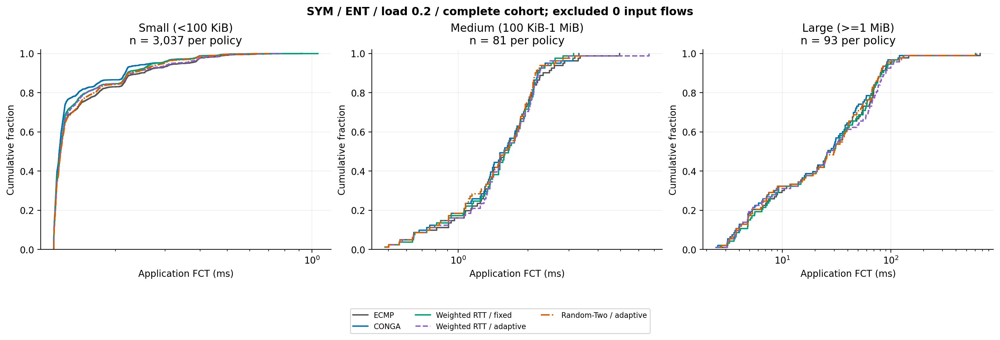

### SYM / target load 0.2: Per-load FCT tail

The complementary CDF shows the fraction with application FCT strictly greater than the horizontal value, using logarithmic axes. At a fixed threshold, lower means fewer flows exceed it. The dotted 0.01 reference marks a one-percent tail. Ties are counted together and the zero-probability endpoint is omitted; a curve ending before another is not an incomplete transfer. Sample counts are shown, and the ordinary CDF remains available alongside this view.

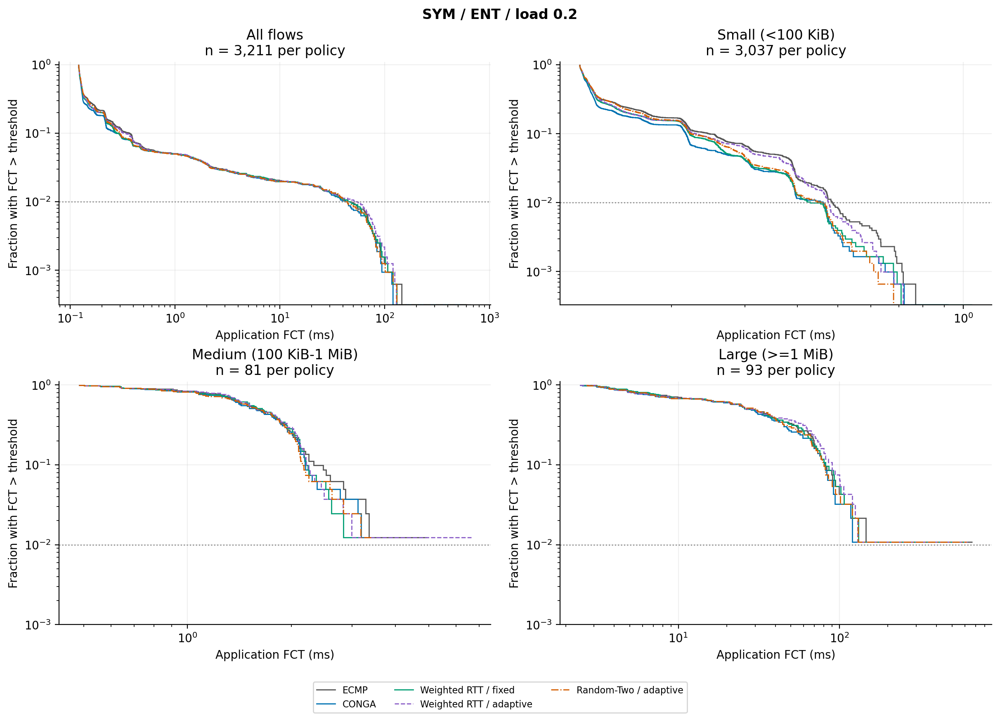

### SYM / target load 0.2: Per-load directed uplink utilization

Each cell is bytes transmitted on that leaf-to-spine link during 0–5 s, divided by that individual link's capacity over five seconds. Cells are not shares of a single total and do not sum to 100%. The reduced Leaf 0–Spine 0 link uses 5 Gb/s for asymmetric runs. Other links use 10 Gb/s. The same color scale is used across all exported heatmaps. Traffic during drain is excluded; these averages do not reveal instantaneous queueing or prove packet reordering.

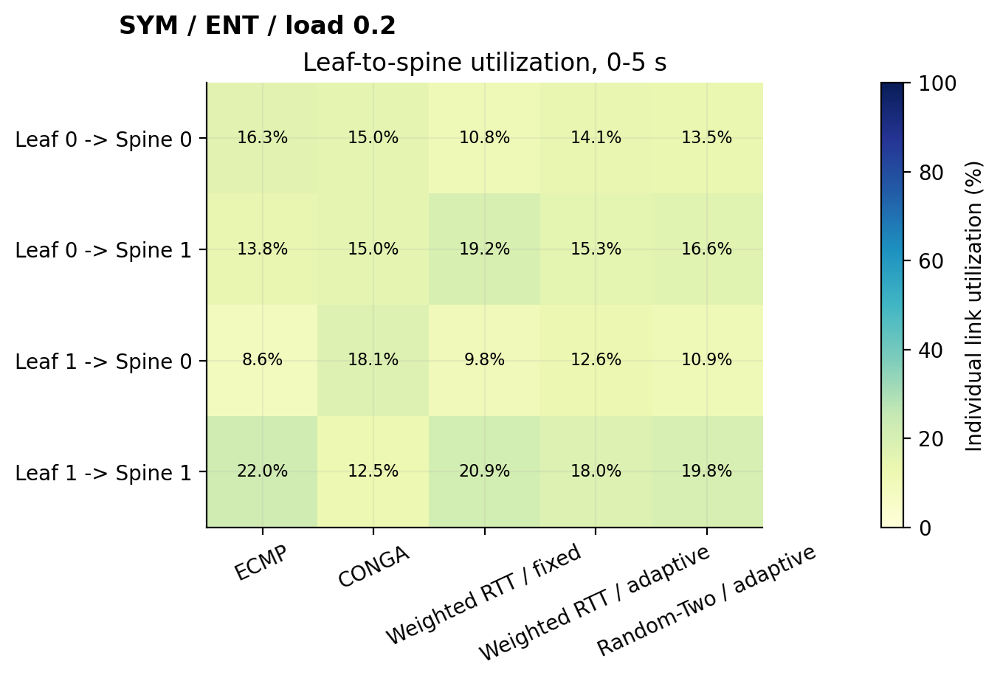

### SYM / target load 0.3: Per-load FCT distribution

Within each size class, the vertical value is the fraction of verified completed flows with application FCT at or below the horizontal value. The horizontal scale is logarithmic; a curve further left reaches a given completion fraction sooner. Step shapes, especially for a small large-flow population, are expected. Each panel gives its number of flows per policy; no sizes are pooled across classes.

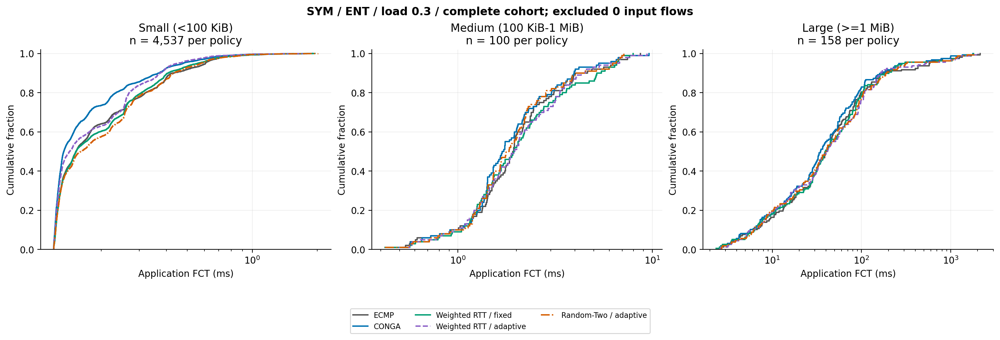

### SYM / target load 0.3: Per-load FCT tail

The complementary CDF shows the fraction with application FCT strictly greater than the horizontal value, using logarithmic axes. At a fixed threshold, lower means fewer flows exceed it. The dotted 0.01 reference marks a one-percent tail. Ties are counted together and the zero-probability endpoint is omitted; a curve ending before another is not an incomplete transfer. Sample counts are shown, and the ordinary CDF remains available alongside this view.

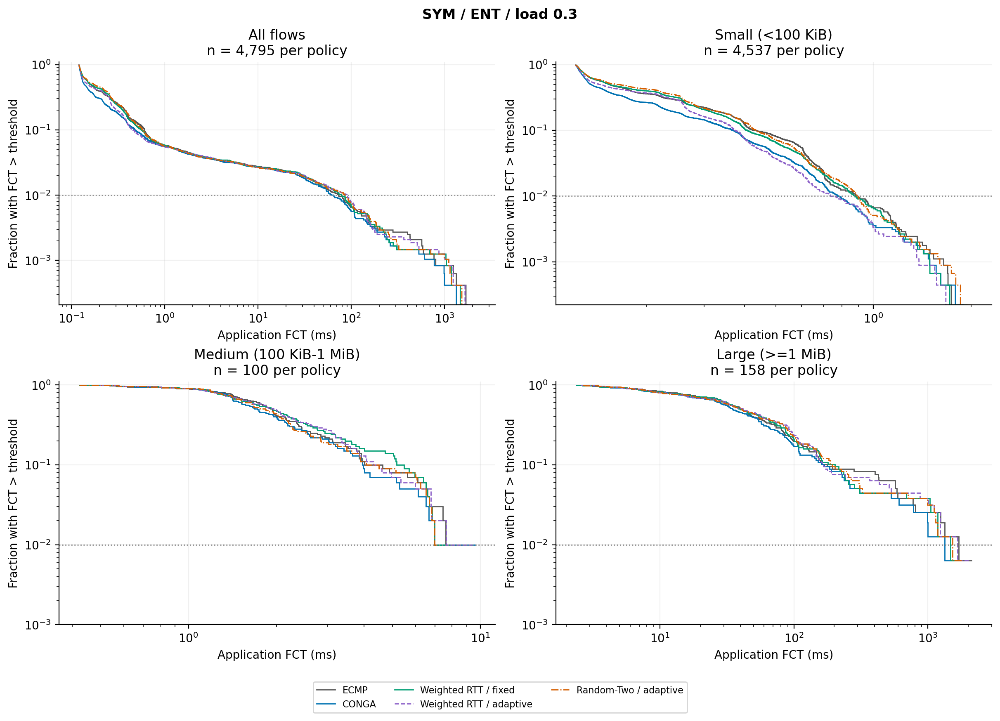

### SYM / target load 0.3: Per-load directed uplink utilization

Each cell is bytes transmitted on that leaf-to-spine link during 0–5 s, divided by that individual link's capacity over five seconds. Cells are not shares of a single total and do not sum to 100%. The reduced Leaf 0–Spine 0 link uses 5 Gb/s for asymmetric runs. Other links use 10 Gb/s. The same color scale is used across all exported heatmaps. Traffic during drain is excluded; these averages do not reveal instantaneous queueing or prove packet reordering.

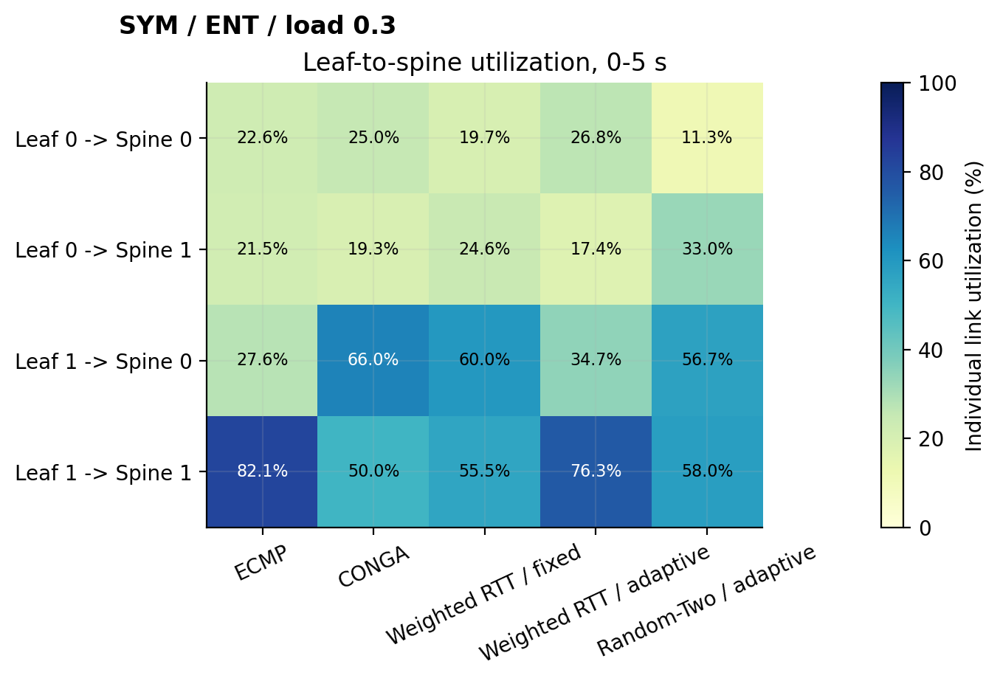

### SYM / target load 0.4: Per-load FCT distribution

Within each size class, the vertical value is the fraction of verified completed flows with application FCT at or below the horizontal value. The horizontal scale is logarithmic; a curve further left reaches a given completion fraction sooner. Step shapes, especially for a small large-flow population, are expected. Each panel gives its number of flows per policy; no sizes are pooled across classes.

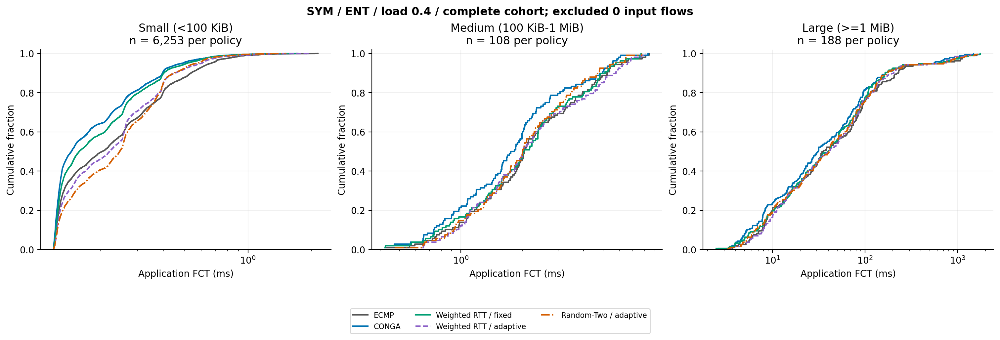

### SYM / target load 0.4: Per-load FCT tail

The complementary CDF shows the fraction with application FCT strictly greater than the horizontal value, using logarithmic axes. At a fixed threshold, lower means fewer flows exceed it. The dotted 0.01 reference marks a one-percent tail. Ties are counted together and the zero-probability endpoint is omitted; a curve ending before another is not an incomplete transfer. Sample counts are shown, and the ordinary CDF remains available alongside this view.

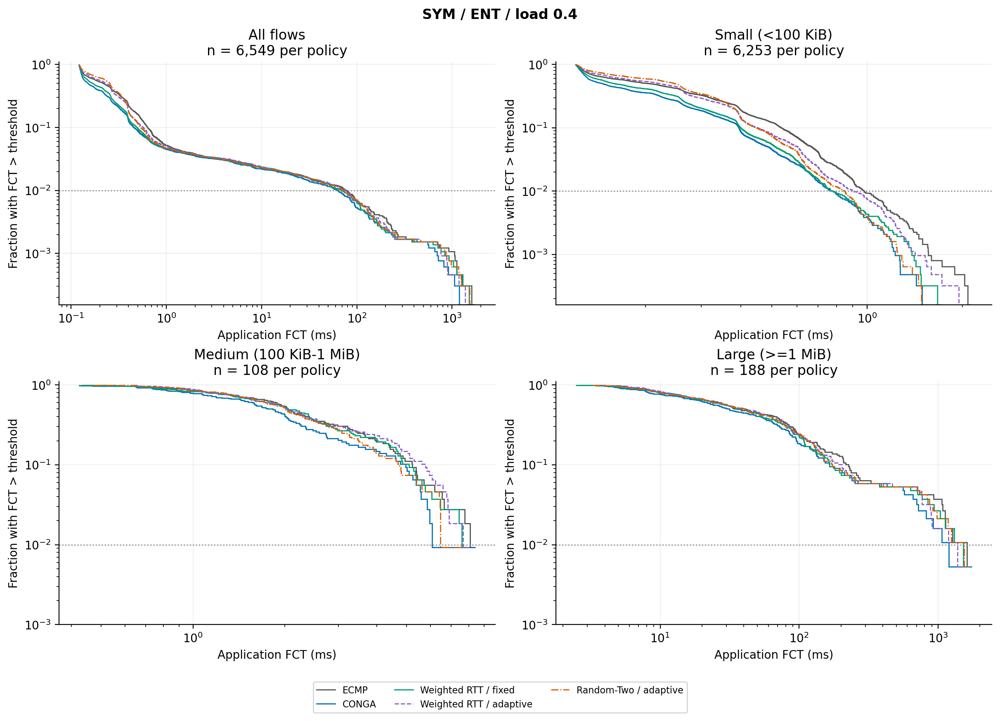

### SYM / target load 0.4: Per-load directed uplink utilization

Each cell is bytes transmitted on that leaf-to-spine link during 0–5 s, divided by that individual link's capacity over five seconds. Cells are not shares of a single total and do not sum to 100%. The reduced Leaf 0–Spine 0 link uses 5 Gb/s for asymmetric runs. Other links use 10 Gb/s. The same color scale is used across all exported heatmaps. Traffic during drain is excluded; these averages do not reveal instantaneous queueing or prove packet reordering.

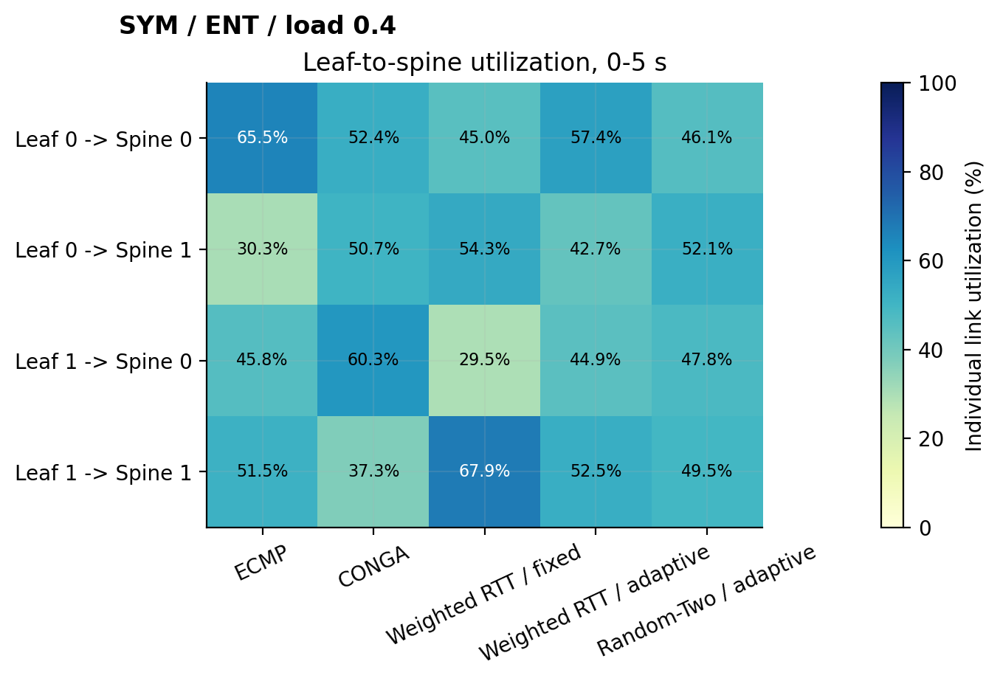

### SYM / target load 0.5: Per-load FCT distribution

Within each size class, the vertical value is the fraction of verified completed flows with application FCT at or below the horizontal value. The horizontal scale is logarithmic; a curve further left reaches a given completion fraction sooner. Step shapes, especially for a small large-flow population, are expected. Each panel gives its number of flows per policy; no sizes are pooled across classes.

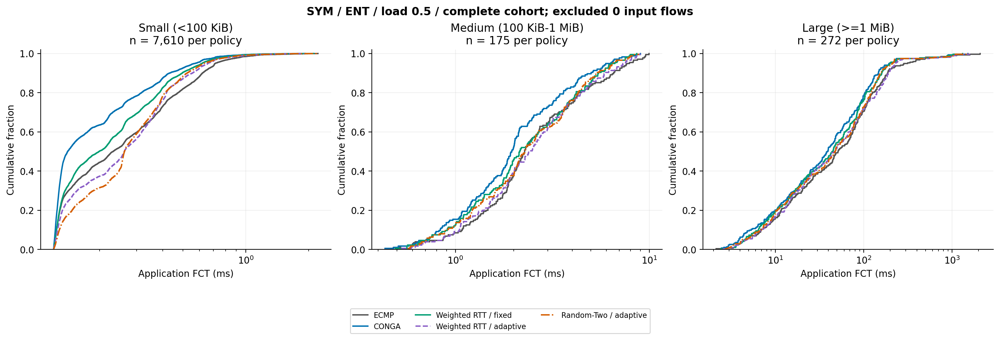

### SYM / target load 0.5: Per-load FCT tail

The complementary CDF shows the fraction with application FCT strictly greater than the horizontal value, using logarithmic axes. At a fixed threshold, lower means fewer flows exceed it. The dotted 0.01 reference marks a one-percent tail. Ties are counted together and the zero-probability endpoint is omitted; a curve ending before another is not an incomplete transfer. Sample counts are shown, and the ordinary CDF remains available alongside this view.

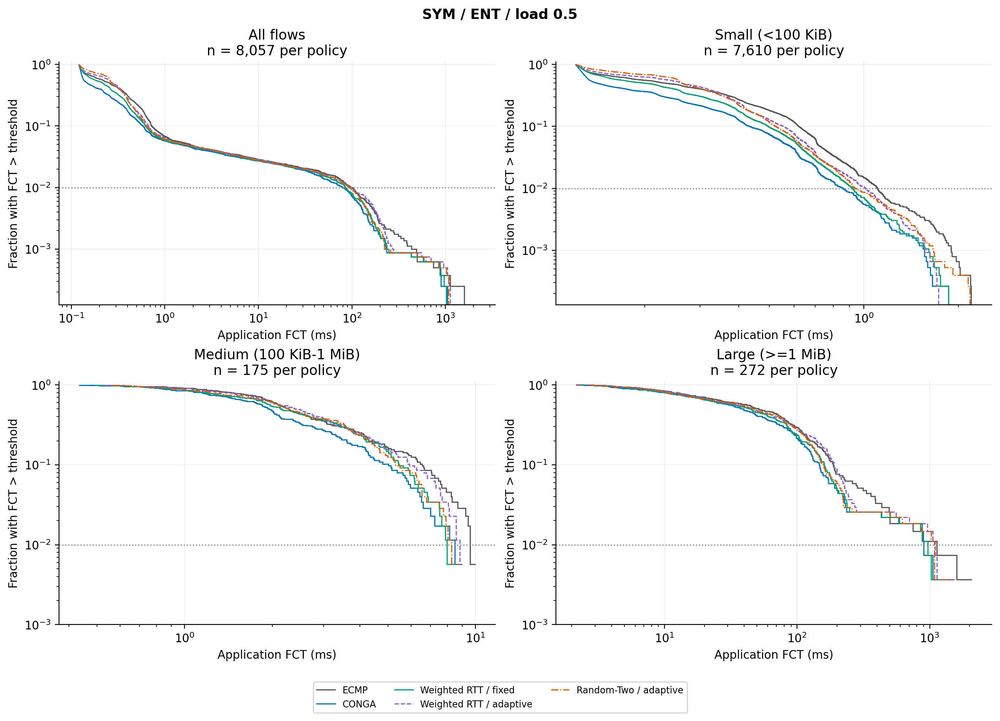

### SYM / target load 0.5: Per-load directed uplink utilization

Each cell is bytes transmitted on that leaf-to-spine link during 0–5 s, divided by that individual link's capacity over five seconds. Cells are not shares of a single total and do not sum to 100%. The reduced Leaf 0–Spine 0 link uses 5 Gb/s for asymmetric runs. Other links use 10 Gb/s. The same color scale is used across all exported heatmaps. Traffic during drain is excluded; these averages do not reveal instantaneous queueing or prove packet reordering.

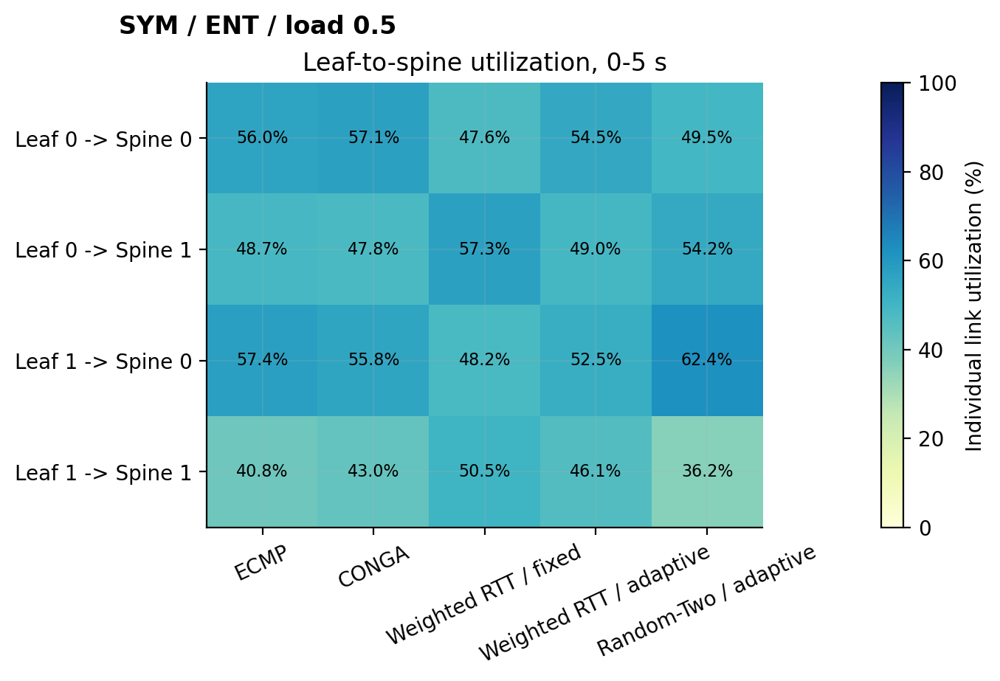

### SYM / target load 0.6: Per-load FCT distribution

Within each size class, the vertical value is the fraction of verified completed flows with application FCT at or below the horizontal value. The horizontal scale is logarithmic; a curve further left reaches a given completion fraction sooner. Step shapes, especially for a small large-flow population, are expected. Each panel gives its number of flows per policy; no sizes are pooled across classes.

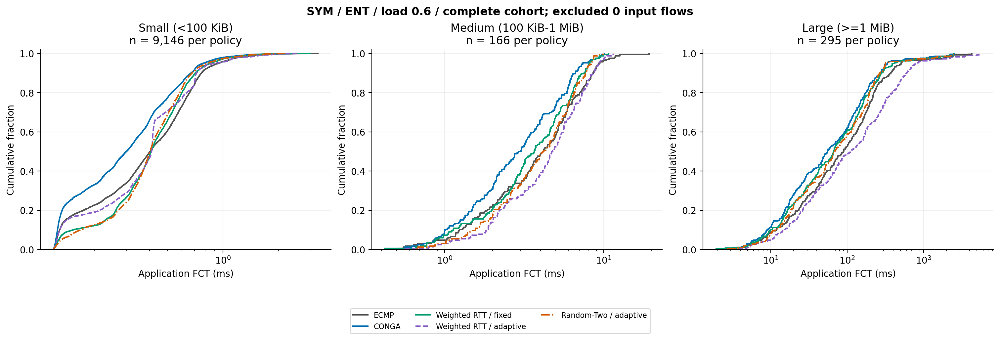

### SYM / target load 0.6: Per-load FCT tail

The complementary CDF shows the fraction with application FCT strictly greater than the horizontal value, using logarithmic axes. At a fixed threshold, lower means fewer flows exceed it. The dotted 0.01 reference marks a one-percent tail. Ties are counted together and the zero-probability endpoint is omitted; a curve ending before another is not an incomplete transfer. Sample counts are shown, and the ordinary CDF remains available alongside this view.

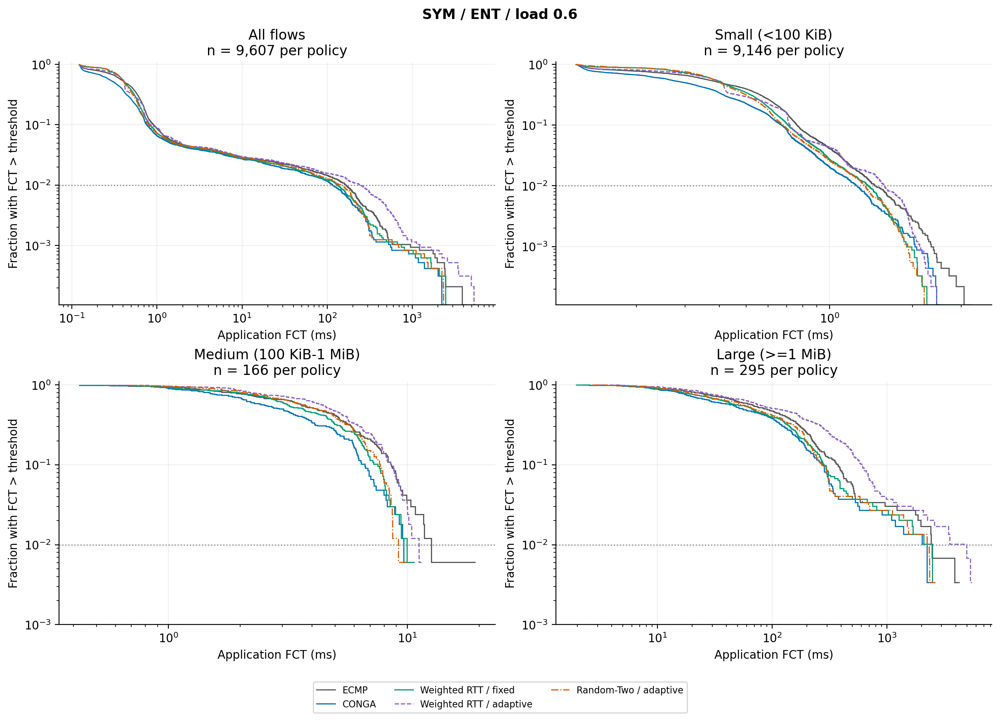

### SYM / target load 0.6: Per-load directed uplink utilization

Each cell is bytes transmitted on that leaf-to-spine link during 0–5 s, divided by that individual link's capacity over five seconds. Cells are not shares of a single total and do not sum to 100%. The reduced Leaf 0–Spine 0 link uses 5 Gb/s for asymmetric runs. Other links use 10 Gb/s. The same color scale is used across all exported heatmaps. Traffic during drain is excluded; these averages do not reveal instantaneous queueing or prove packet reordering.

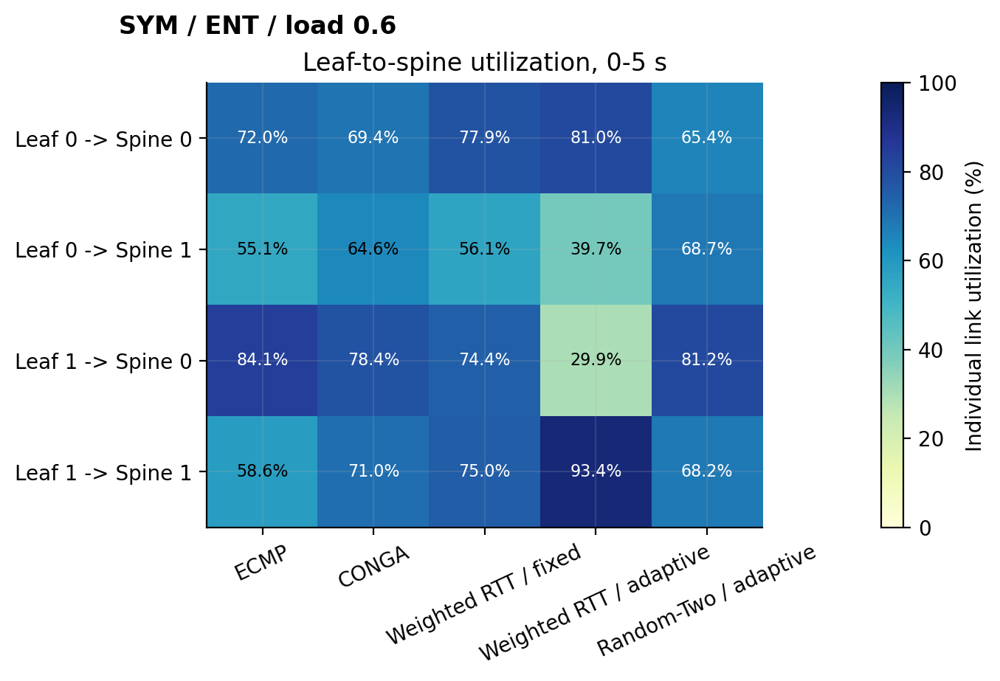

### SYM / target load 0.7: Per-load FCT distribution

Within each size class, the vertical value is the fraction of verified completed flows with application FCT at or below the horizontal value. The horizontal scale is logarithmic; a curve further left reaches a given completion fraction sooner. Step shapes, especially for a small large-flow population, are expected. Each panel gives its number of flows per policy; no sizes are pooled across classes.

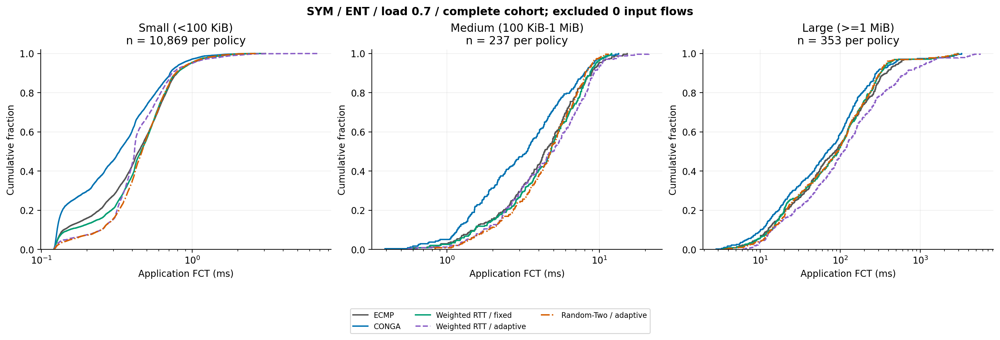

### SYM / target load 0.7: Per-load FCT tail

The complementary CDF shows the fraction with application FCT strictly greater than the horizontal value, using logarithmic axes. At a fixed threshold, lower means fewer flows exceed it. The dotted 0.01 reference marks a one-percent tail. Ties are counted together and the zero-probability endpoint is omitted; a curve ending before another is not an incomplete transfer. Sample counts are shown, and the ordinary CDF remains available alongside this view.

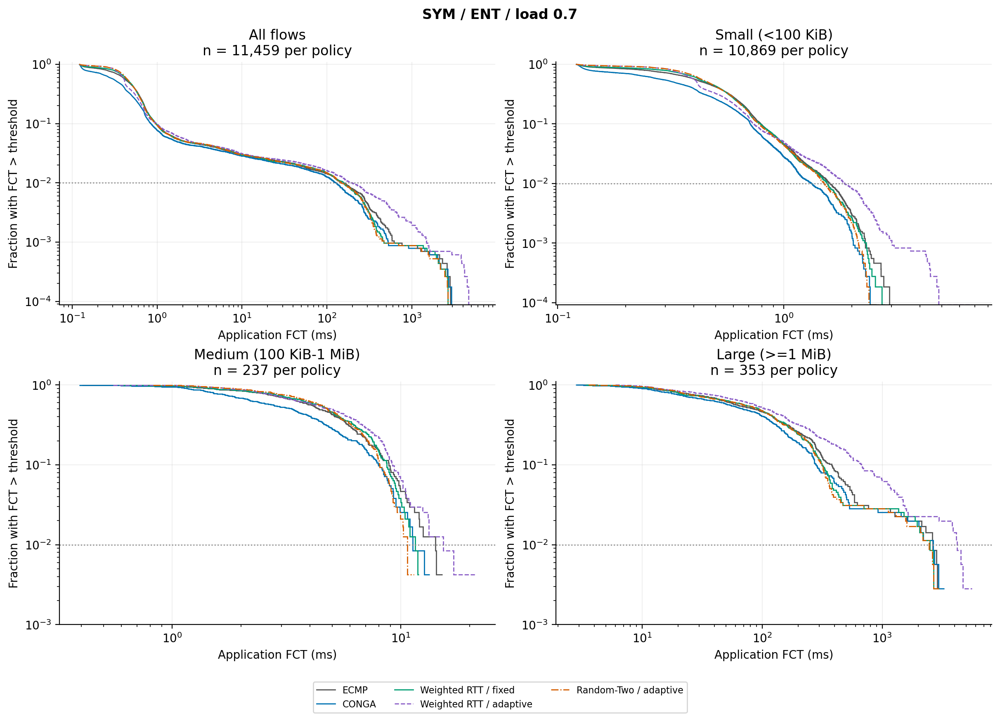

### SYM / target load 0.7: Per-load directed uplink utilization

Each cell is bytes transmitted on that leaf-to-spine link during 0–5 s, divided by that individual link's capacity over five seconds. Cells are not shares of a single total and do not sum to 100%. The reduced Leaf 0–Spine 0 link uses 5 Gb/s for asymmetric runs. Other links use 10 Gb/s. The same color scale is used across all exported heatmaps. Traffic during drain is excluded; these averages do not reveal instantaneous queueing or prove packet reordering.

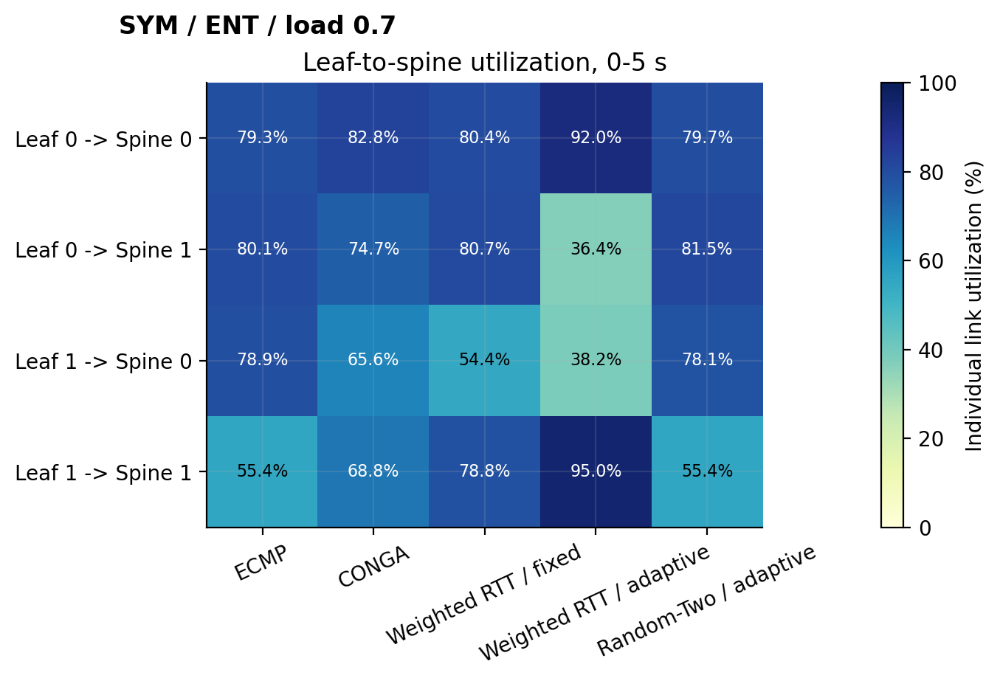

### SYM / target load 0.8: Per-load FCT distribution

Within each size class, the vertical value is the fraction of verified completed flows with application FCT at or below the horizontal value. The horizontal scale is logarithmic; a curve further left reaches a given completion fraction sooner. Step shapes, especially for a small large-flow population, are expected. Each panel gives its number of flows per policy; no sizes are pooled across classes.

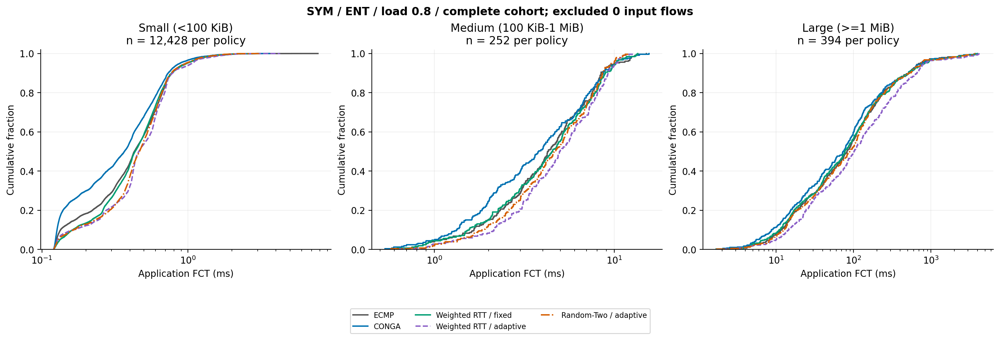

### SYM / target load 0.8: Per-load FCT tail

The complementary CDF shows the fraction with application FCT strictly greater than the horizontal value, using logarithmic axes. At a fixed threshold, lower means fewer flows exceed it. The dotted 0.01 reference marks a one-percent tail. Ties are counted together and the zero-probability endpoint is omitted; a curve ending before another is not an incomplete transfer. Sample counts are shown, and the ordinary CDF remains available alongside this view.

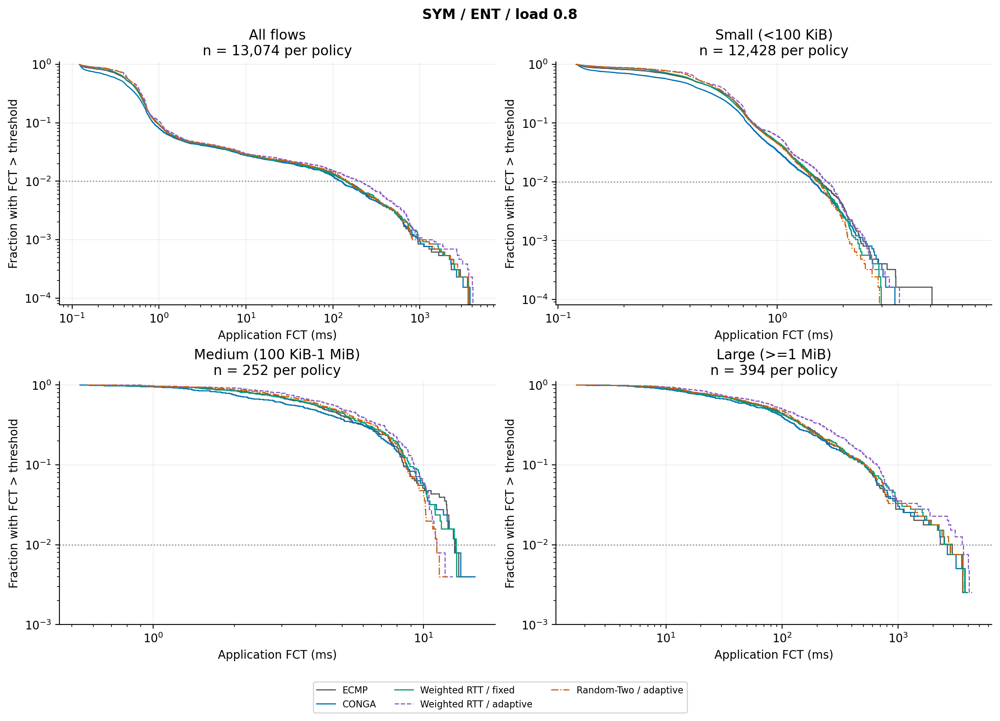

### SYM / target load 0.8: Per-load directed uplink utilization

Each cell is bytes transmitted on that leaf-to-spine link during 0–5 s, divided by that individual link's capacity over five seconds. Cells are not shares of a single total and do not sum to 100%. The reduced Leaf 0–Spine 0 link uses 5 Gb/s for asymmetric runs. Other links use 10 Gb/s. The same color scale is used across all exported heatmaps. Traffic during drain is excluded; these averages do not reveal instantaneous queueing or prove packet reordering.

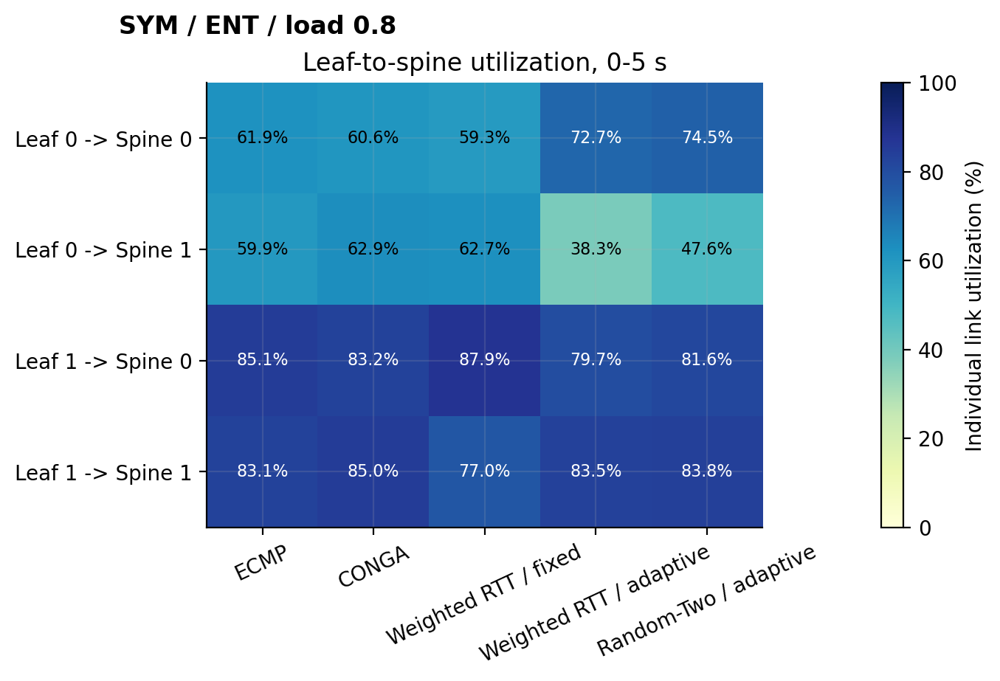

### SYM / target load 0.9: Per-load FCT distribution

Within each size class, the vertical value is the fraction of verified completed flows with application FCT at or below the horizontal value. The horizontal scale is logarithmic; a curve further left reaches a given completion fraction sooner. Step shapes, especially for a small large-flow population, are expected. Each panel gives its number of flows per policy; no sizes are pooled across classes.

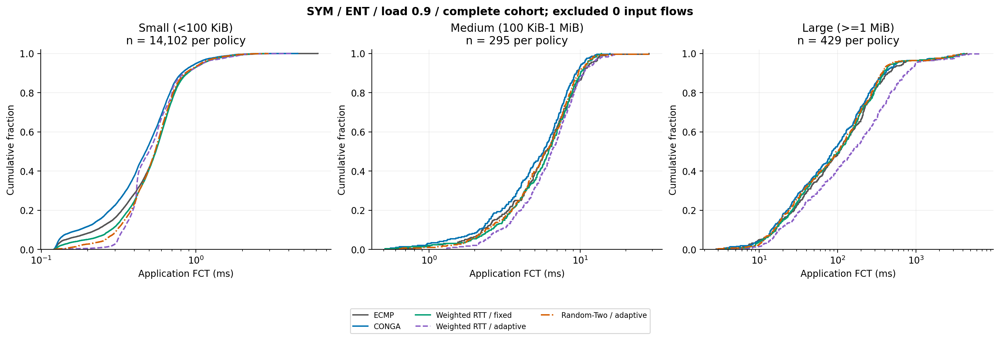

### SYM / target load 0.9: Per-load FCT tail

The complementary CDF shows the fraction with application FCT strictly greater than the horizontal value, using logarithmic axes. At a fixed threshold, lower means fewer flows exceed it. The dotted 0.01 reference marks a one-percent tail. Ties are counted together and the zero-probability endpoint is omitted; a curve ending before another is not an incomplete transfer. Sample counts are shown, and the ordinary CDF remains available alongside this view.

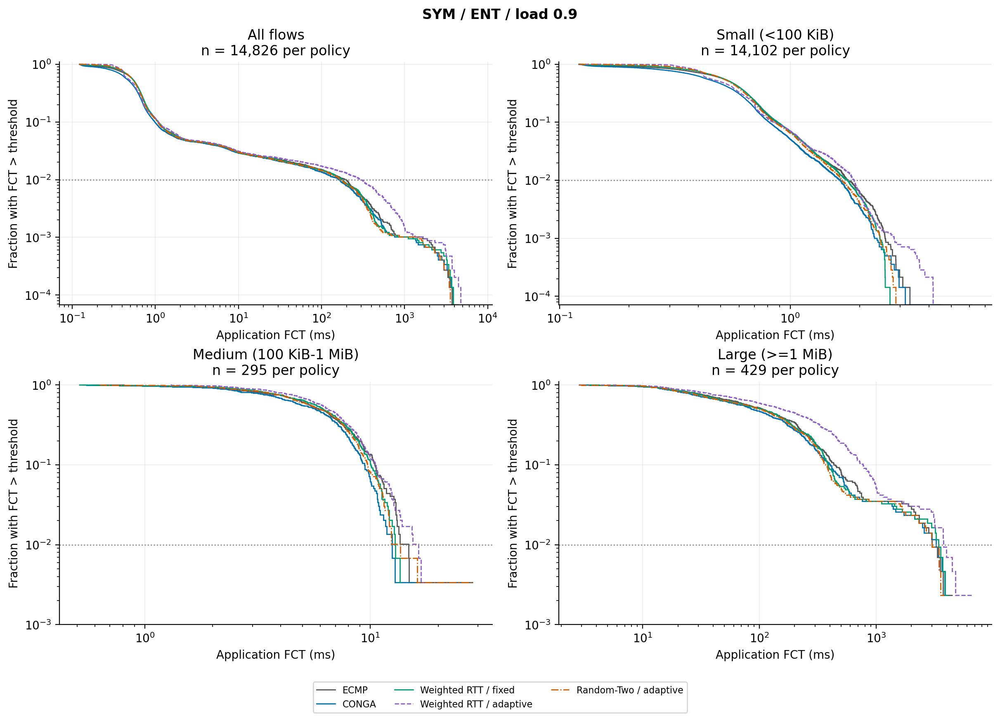

### SYM / target load 0.9: Per-load directed uplink utilization

Each cell is bytes transmitted on that leaf-to-spine link during 0–5 s, divided by that individual link's capacity over five seconds. Cells are not shares of a single total and do not sum to 100%. The reduced Leaf 0–Spine 0 link uses 5 Gb/s for asymmetric runs. Other links use 10 Gb/s. The same color scale is used across all exported heatmaps. Traffic during drain is excluded; these averages do not reveal instantaneous queueing or prove packet reordering.

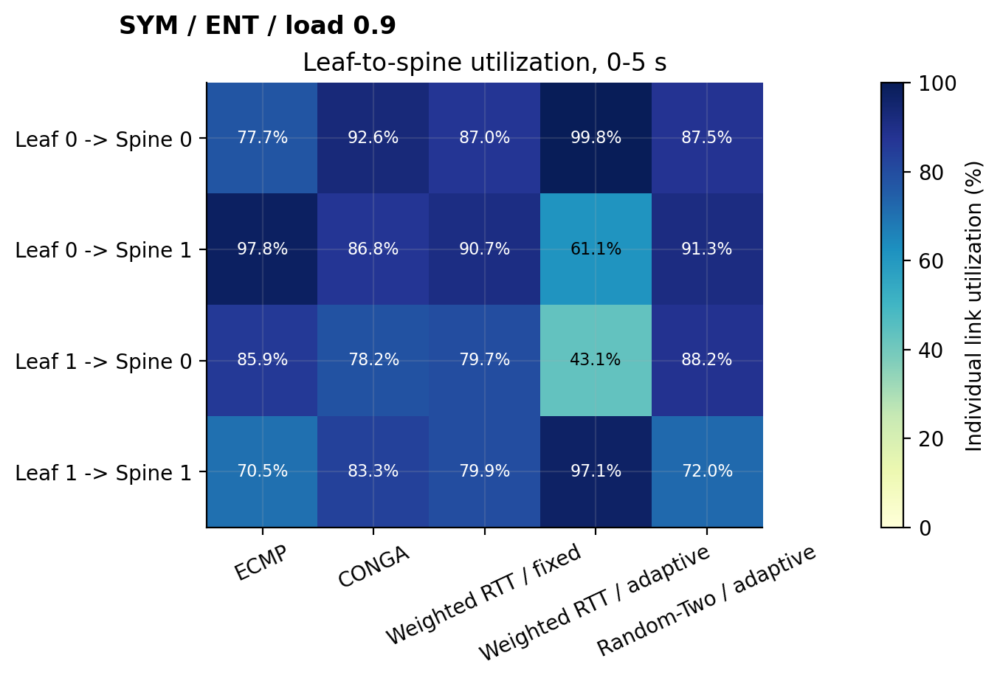

In [5]:
if "sym" in SCENARIOS:
    show_loads("sym")


## Asymmetric fabric: performance across loads

The reduced connection is Leaf 0–Spine 0 at 5 Gb/s. Compare algorithms within
this topology using the same trace. At a given target-load label, this fabric
has less capacity than the symmetric one. CONGA's reduced-link congestion
accounting is enabled by the experiment runner; RTT policies observe delay,
while ECMP retains its per-flow hash assignment.

Lower utilization on the reduced link alone does not establish better load
balancing. Read it together with FCT on all paths, byte delivery, and drops.
Avoiding the reduced link can concentrate traffic on another path, while using
it can either add useful capacity or delay flows.


### ASYM: Overall mean application FCT

The left panel shows the arithmetic mean over all input flows, in milliseconds on a logarithmic axis. The right divides each mean by CONGA's mean for the same flows; lower is better and one equals CONGA. Small and large transfers each contribute one FCT value. The overall mean is not an average of the size-class means. Compare within a topology; asymmetric experiments have less capacity.

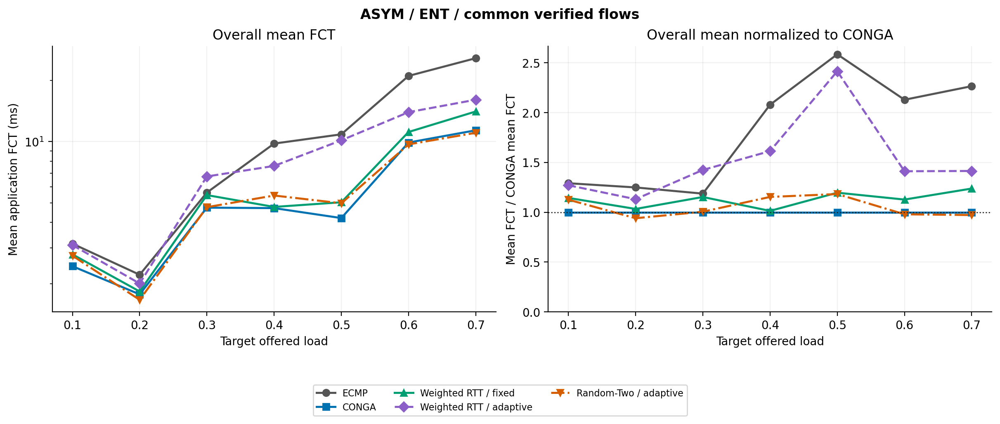

### ASYM: Overall p99 application FCT

The left panel is the sample 99th percentile over all flow sizes. The right is the ratio of that percentile to CONGA's percentile for the same input-flow cohort. A larger mean improvement can coexist with a worse p99. These are quantiles of one simulation's flow population, not confidence intervals across repeated runs.

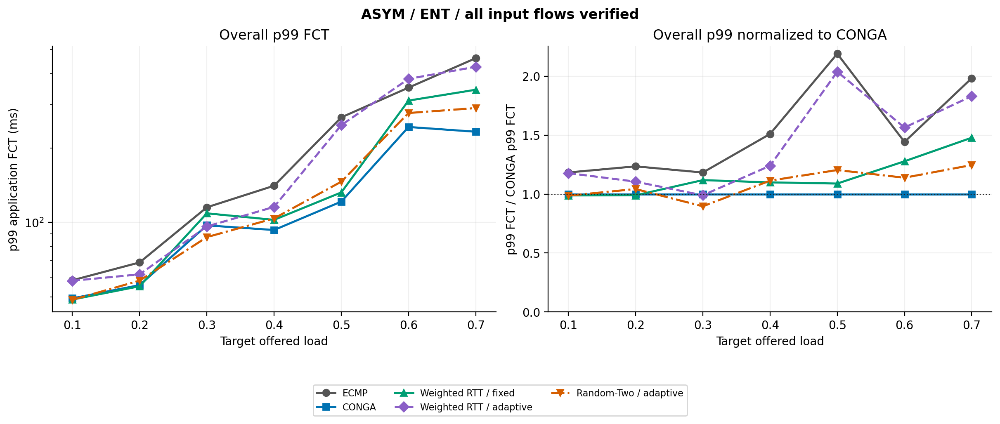

### ASYM: Mean and p99 FCT by flow size

Columns split flows at 100 KiB and 1 MiB; rows show the arithmetic mean and sample p99. The vertical axes are logarithmic and may have different scales. Inspect large-flow behavior separately from small-flow latency. The fct_summary.csv file records the sample count for each class; a p99 from a small class depends on very few flows.

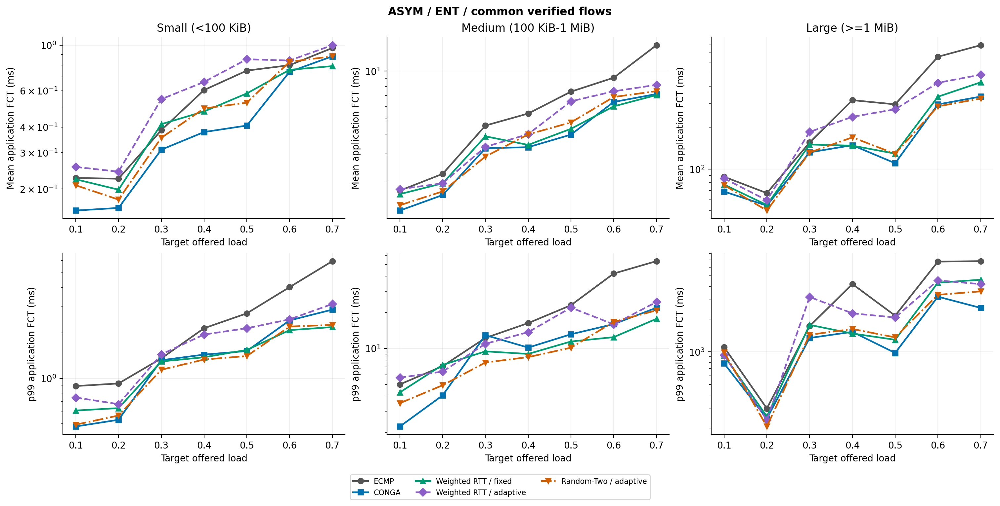

### ASYM: Size-class mean FCT relative to ECMP

Each point is mean(policy FCT) / mean(ECMP FCT) in the same size class and matched cohort. Below one means a lower mean FCT than ECMP; above one means a higher mean. This is a ratio of means, not the mean of individual flow ratios. The denominator is ECMP, unlike the overall normalized panels.

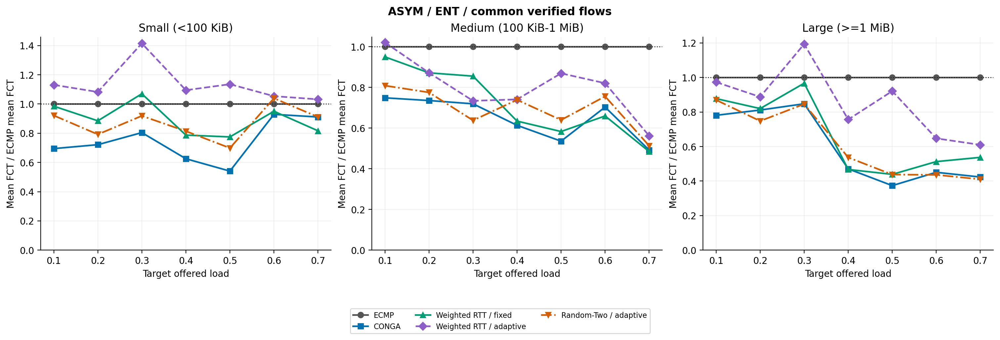

### ASYM: Size-class p99 FCT relative to ECMP

Each point divides the policy's sample p99 by ECMP's sample p99 over the same size class and flow cohort. Below one means a lower tail percentile. A p99 ratio is not the 99th percentile of per-flow speedups, and it does not describe run-to-run uncertainty.

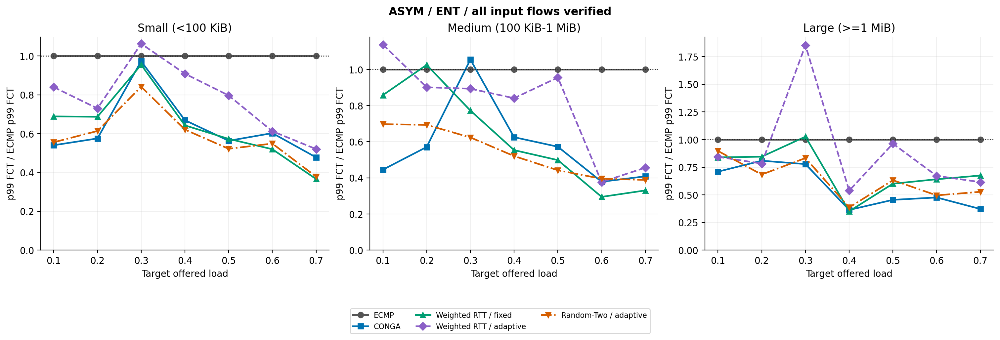

### ASYM: Forward TCP packet loss

FlowMonitor lost packets divided by transmitted packets, multiplied by 100, for forward TCP connections matched uniquely to the input flows. This includes connection-control traffic on those connections; it is not a fraction of missing payload bytes or a count of all retransmissions. Zero means no recorded forward losses under this counter.

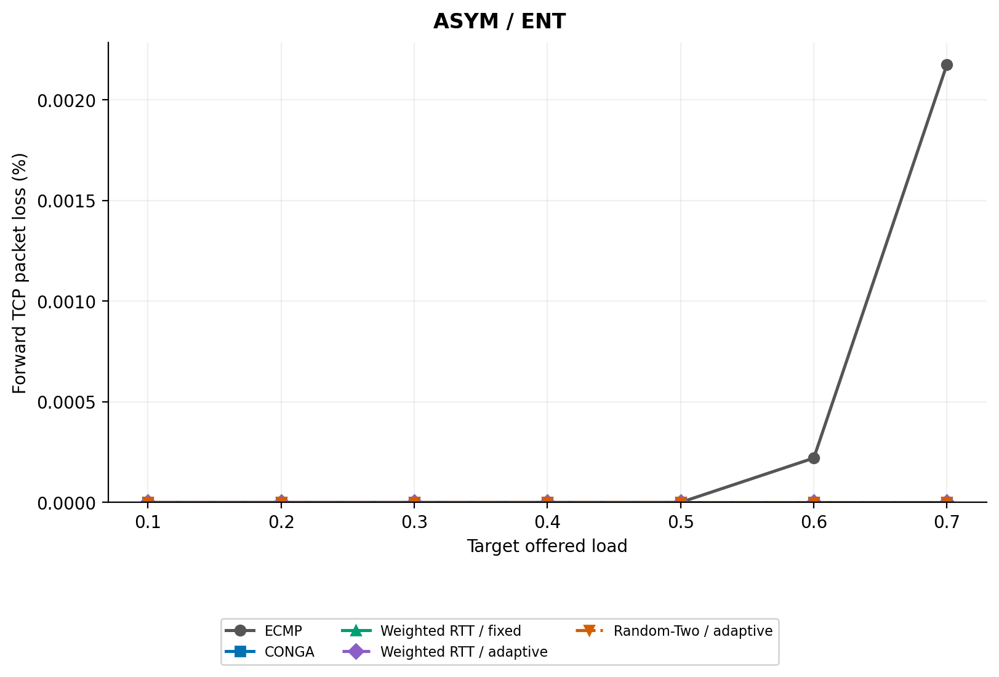

### ASYM: Packet loss and queue drops

The panels show forward FlowMonitor loss, root queue-disc drops across all interfaces and directions, root drops per delivered MiB, and device-queue drops. These counters have different scopes and may refer to overlapping packet events; do not add them. Root FqCoDel drops may represent queue management, not merely a physically full device queue. Event-stage and reason tables are exported under each topology's summary folder. Coincident zero-valued curves can cover one another.

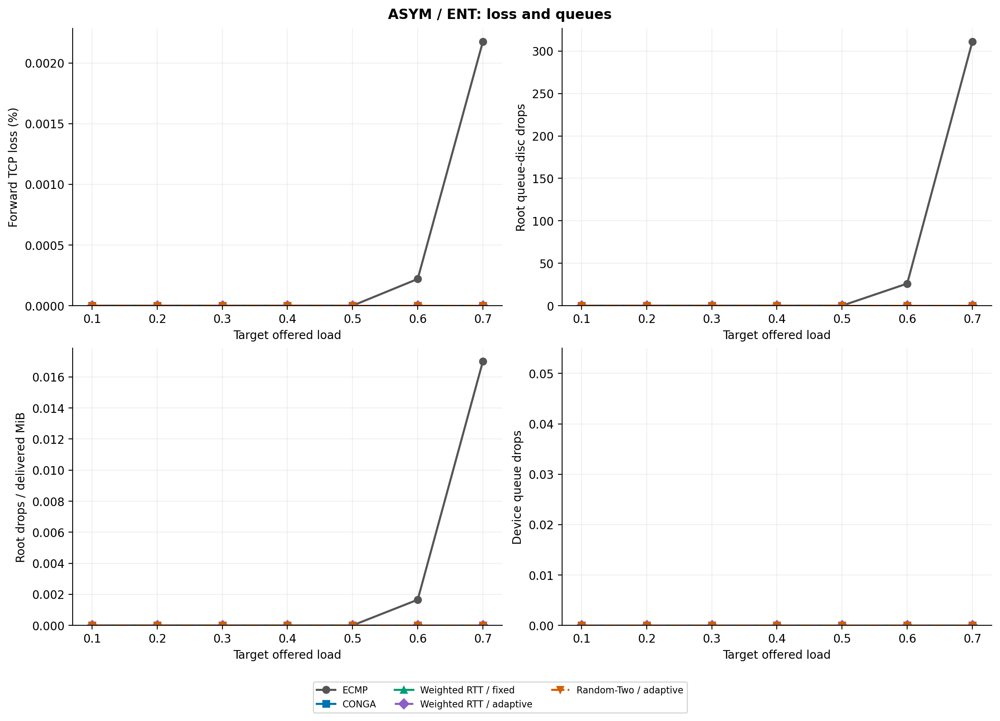

In [6]:
if "asym" in SCENARIOS:
    show_kinds("asym", OVERVIEW_KINDS)
else:
    display(Markdown("The selected snapshot does not include asymmetric runs."))


## Asymmetric fabric: distributions and link use at each load

The physical capacity of the reduced link is used for the heatmaps. A cell at
50% therefore represents a different byte rate on a 5 Gb/s link than on a
10 Gb/s link. All heatmaps use the same color scale, so their percentages remain
visually comparable across policies and loads.

A longer FCT tail may be consistent with queueing, path changes, transport
recovery, or several effects together. These summaries alone do not identify
packet reordering as the cause; that requires packet or TCP-state evidence.


### ASYM / target load 0.1: Per-load FCT distribution

Within each size class, the vertical value is the fraction of verified completed flows with application FCT at or below the horizontal value. The horizontal scale is logarithmic; a curve further left reaches a given completion fraction sooner. Step shapes, especially for a small large-flow population, are expected. Each panel gives its number of flows per policy; no sizes are pooled across classes.

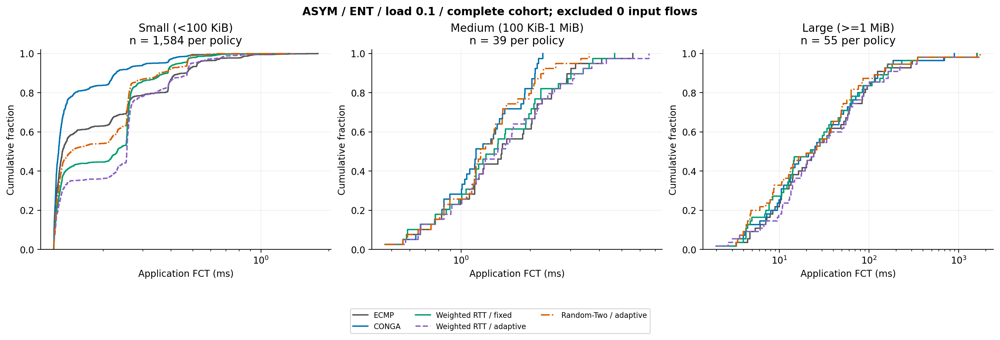

### ASYM / target load 0.1: Per-load FCT tail

The complementary CDF shows the fraction with application FCT strictly greater than the horizontal value, using logarithmic axes. At a fixed threshold, lower means fewer flows exceed it. The dotted 0.01 reference marks a one-percent tail. Ties are counted together and the zero-probability endpoint is omitted; a curve ending before another is not an incomplete transfer. Sample counts are shown, and the ordinary CDF remains available alongside this view.

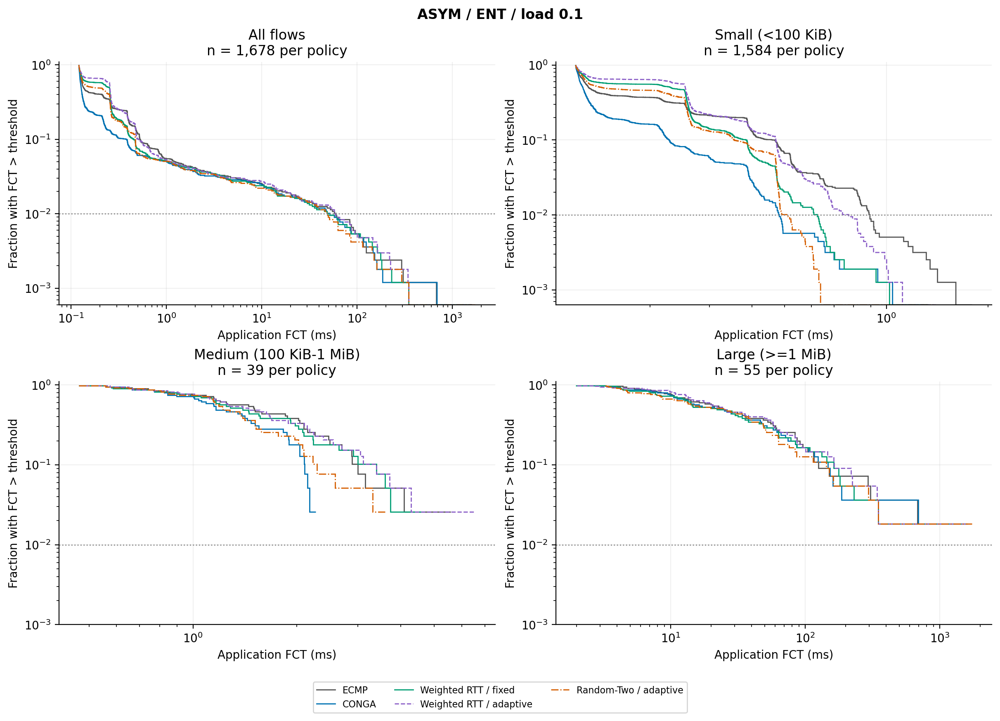

### ASYM / target load 0.1: Per-load directed uplink utilization

Each cell is bytes transmitted on that leaf-to-spine link during 0–5 s, divided by that individual link's capacity over five seconds. Cells are not shares of a single total and do not sum to 100%. The reduced Leaf 0–Spine 0 link uses 5 Gb/s for asymmetric runs. Other links use 10 Gb/s. The same color scale is used across all exported heatmaps. Traffic during drain is excluded; these averages do not reveal instantaneous queueing or prove packet reordering.

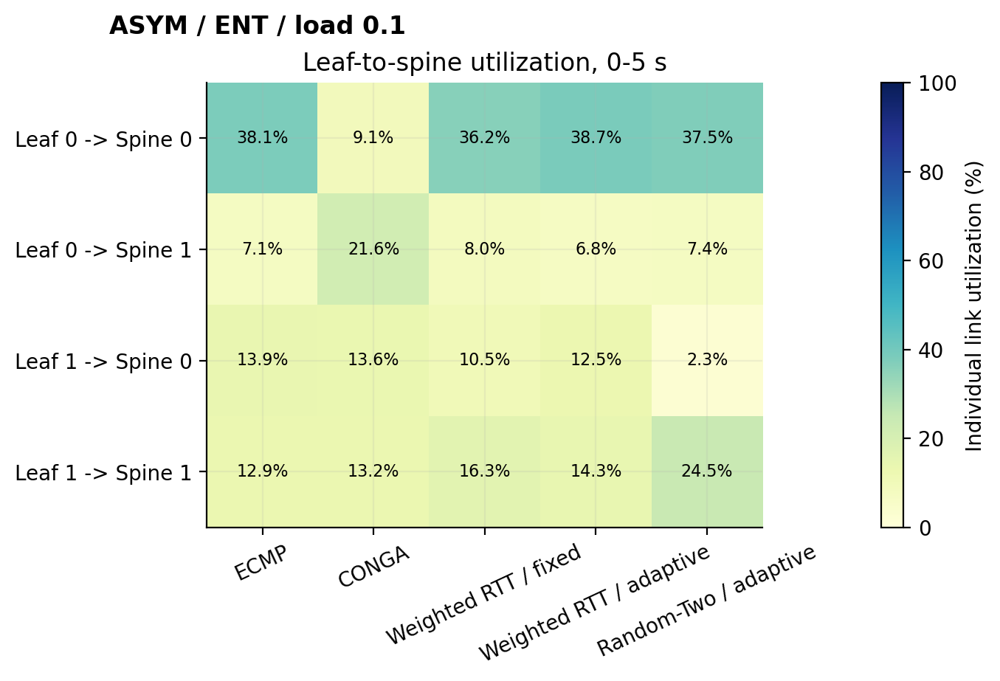

### ASYM / target load 0.2: Per-load FCT distribution

Within each size class, the vertical value is the fraction of verified completed flows with application FCT at or below the horizontal value. The horizontal scale is logarithmic; a curve further left reaches a given completion fraction sooner. Step shapes, especially for a small large-flow population, are expected. Each panel gives its number of flows per policy; no sizes are pooled across classes.

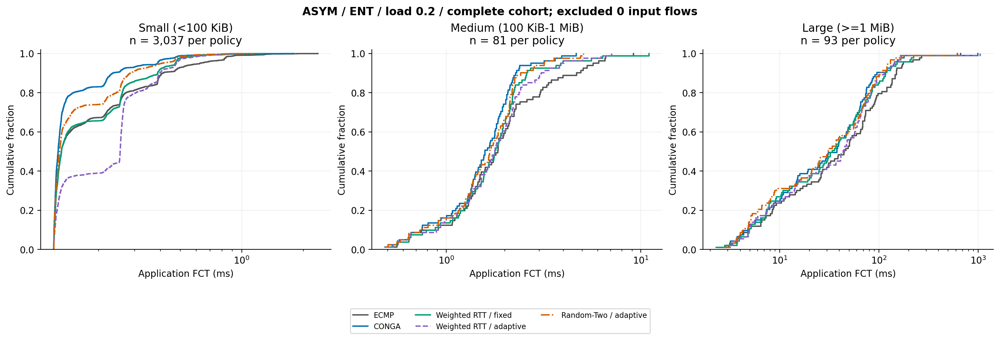

### ASYM / target load 0.2: Per-load FCT tail

The complementary CDF shows the fraction with application FCT strictly greater than the horizontal value, using logarithmic axes. At a fixed threshold, lower means fewer flows exceed it. The dotted 0.01 reference marks a one-percent tail. Ties are counted together and the zero-probability endpoint is omitted; a curve ending before another is not an incomplete transfer. Sample counts are shown, and the ordinary CDF remains available alongside this view.

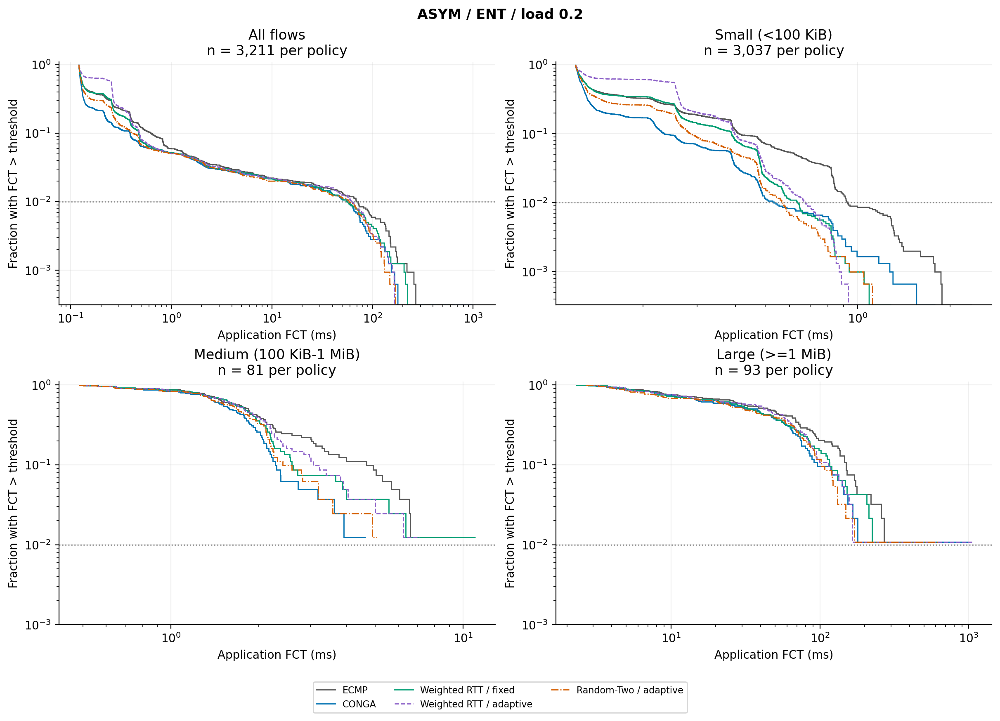

### ASYM / target load 0.2: Per-load directed uplink utilization

Each cell is bytes transmitted on that leaf-to-spine link during 0–5 s, divided by that individual link's capacity over five seconds. Cells are not shares of a single total and do not sum to 100%. The reduced Leaf 0–Spine 0 link uses 5 Gb/s for asymmetric runs. Other links use 10 Gb/s. The same color scale is used across all exported heatmaps. Traffic during drain is excluded; these averages do not reveal instantaneous queueing or prove packet reordering.

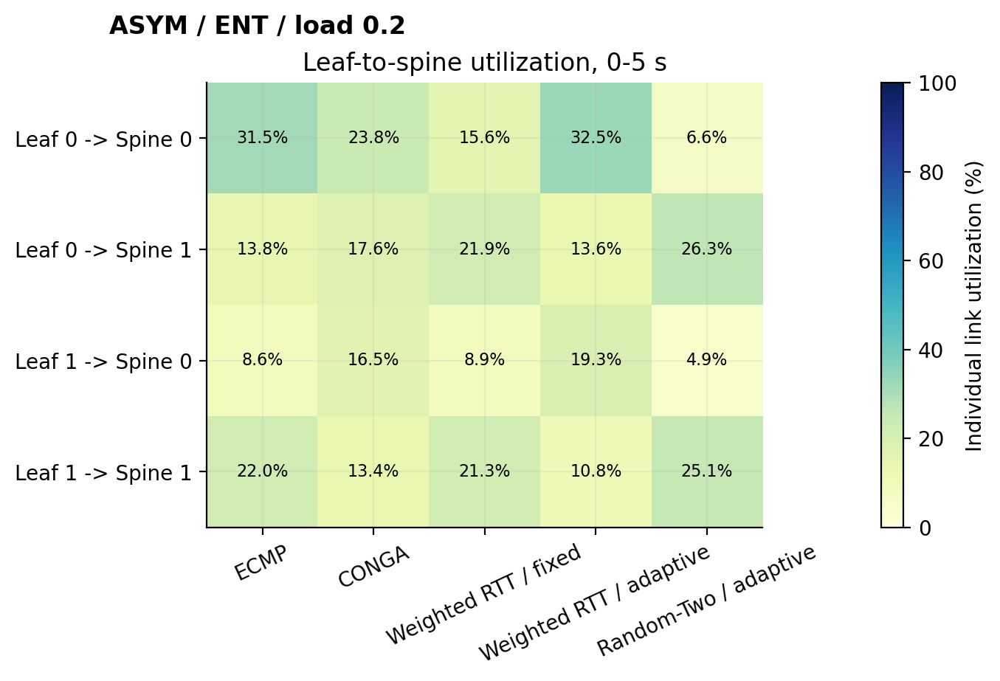

### ASYM / target load 0.3: Per-load FCT distribution

Within each size class, the vertical value is the fraction of verified completed flows with application FCT at or below the horizontal value. The horizontal scale is logarithmic; a curve further left reaches a given completion fraction sooner. Step shapes, especially for a small large-flow population, are expected. Each panel gives its number of flows per policy; no sizes are pooled across classes.

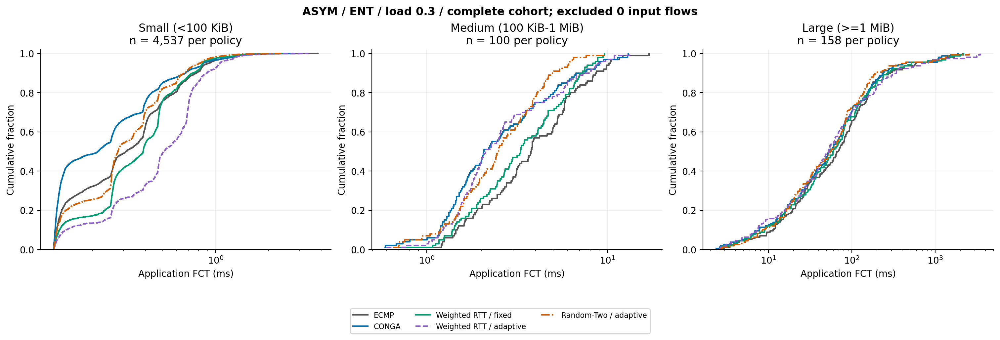

### ASYM / target load 0.3: Per-load FCT tail

The complementary CDF shows the fraction with application FCT strictly greater than the horizontal value, using logarithmic axes. At a fixed threshold, lower means fewer flows exceed it. The dotted 0.01 reference marks a one-percent tail. Ties are counted together and the zero-probability endpoint is omitted; a curve ending before another is not an incomplete transfer. Sample counts are shown, and the ordinary CDF remains available alongside this view.

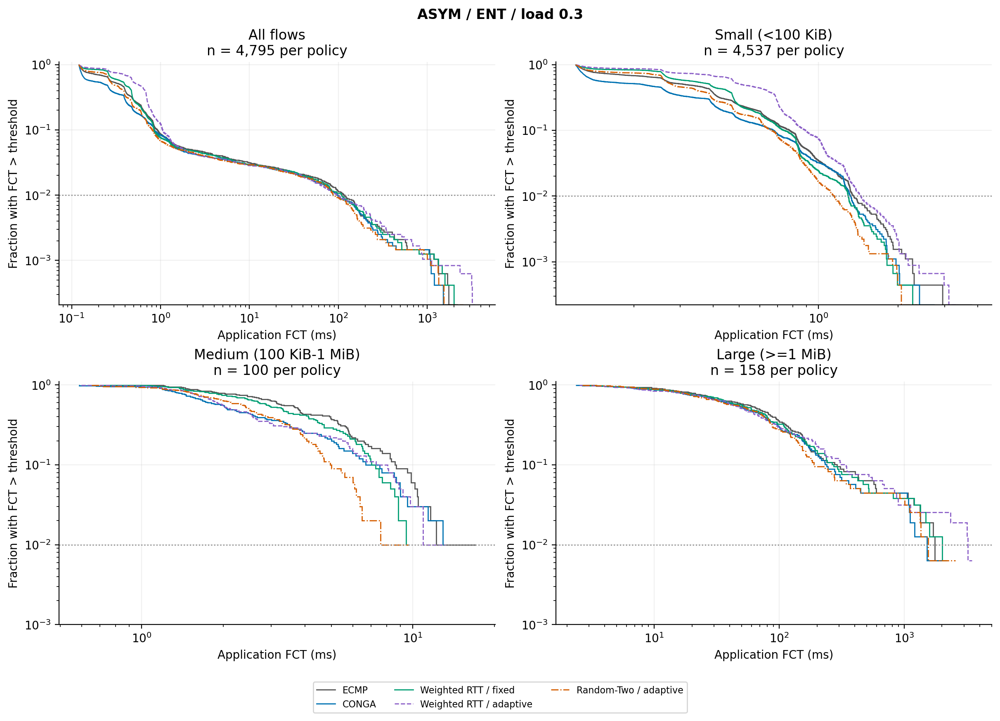

### ASYM / target load 0.3: Per-load directed uplink utilization

Each cell is bytes transmitted on that leaf-to-spine link during 0–5 s, divided by that individual link's capacity over five seconds. Cells are not shares of a single total and do not sum to 100%. The reduced Leaf 0–Spine 0 link uses 5 Gb/s for asymmetric runs. Other links use 10 Gb/s. The same color scale is used across all exported heatmaps. Traffic during drain is excluded; these averages do not reveal instantaneous queueing or prove packet reordering.

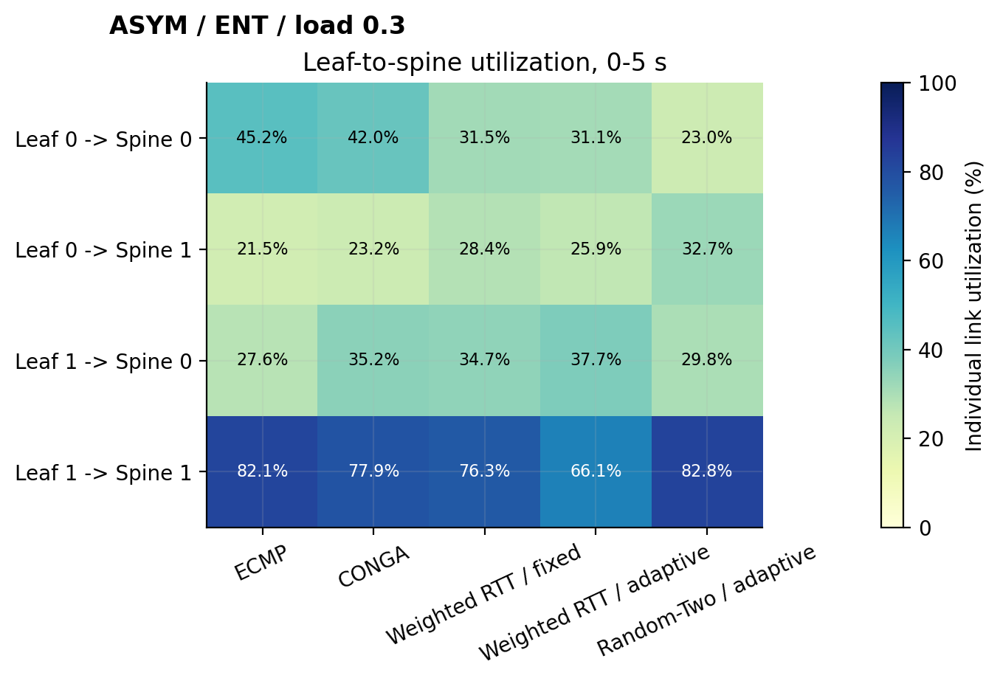

### ASYM / target load 0.4: Per-load FCT distribution

Within each size class, the vertical value is the fraction of verified completed flows with application FCT at or below the horizontal value. The horizontal scale is logarithmic; a curve further left reaches a given completion fraction sooner. Step shapes, especially for a small large-flow population, are expected. Each panel gives its number of flows per policy; no sizes are pooled across classes.

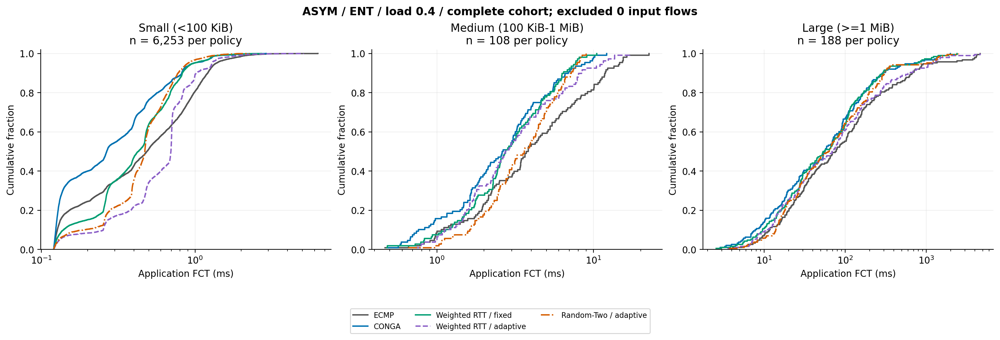

### ASYM / target load 0.4: Per-load FCT tail

The complementary CDF shows the fraction with application FCT strictly greater than the horizontal value, using logarithmic axes. At a fixed threshold, lower means fewer flows exceed it. The dotted 0.01 reference marks a one-percent tail. Ties are counted together and the zero-probability endpoint is omitted; a curve ending before another is not an incomplete transfer. Sample counts are shown, and the ordinary CDF remains available alongside this view.

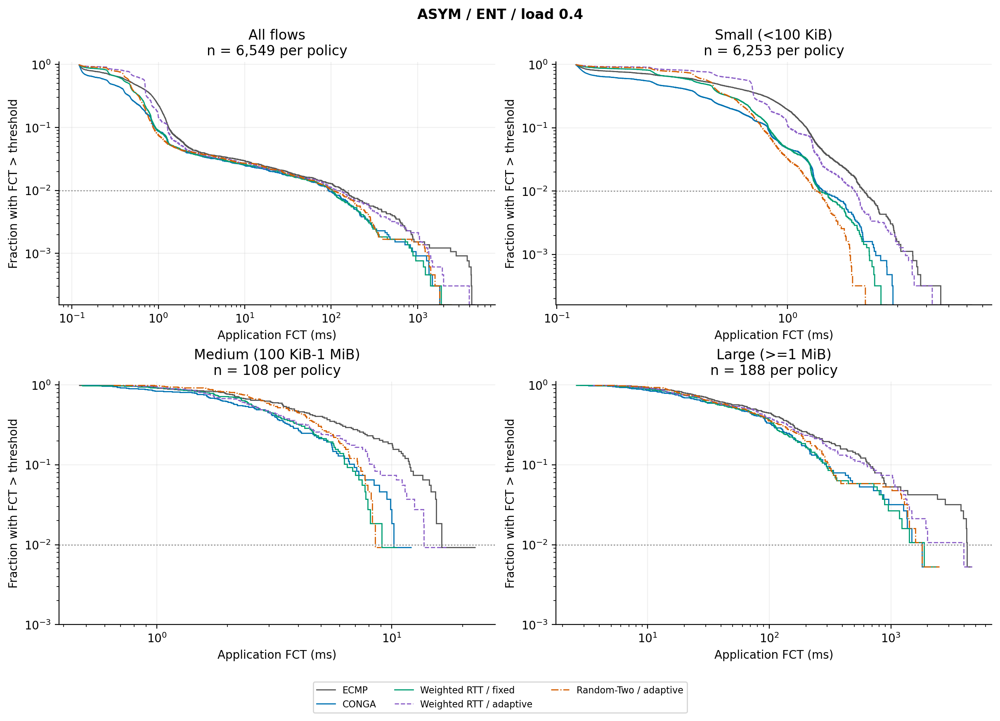

### ASYM / target load 0.4: Per-load directed uplink utilization

Each cell is bytes transmitted on that leaf-to-spine link during 0–5 s, divided by that individual link's capacity over five seconds. Cells are not shares of a single total and do not sum to 100%. The reduced Leaf 0–Spine 0 link uses 5 Gb/s for asymmetric runs. Other links use 10 Gb/s. The same color scale is used across all exported heatmaps. Traffic during drain is excluded; these averages do not reveal instantaneous queueing or prove packet reordering.

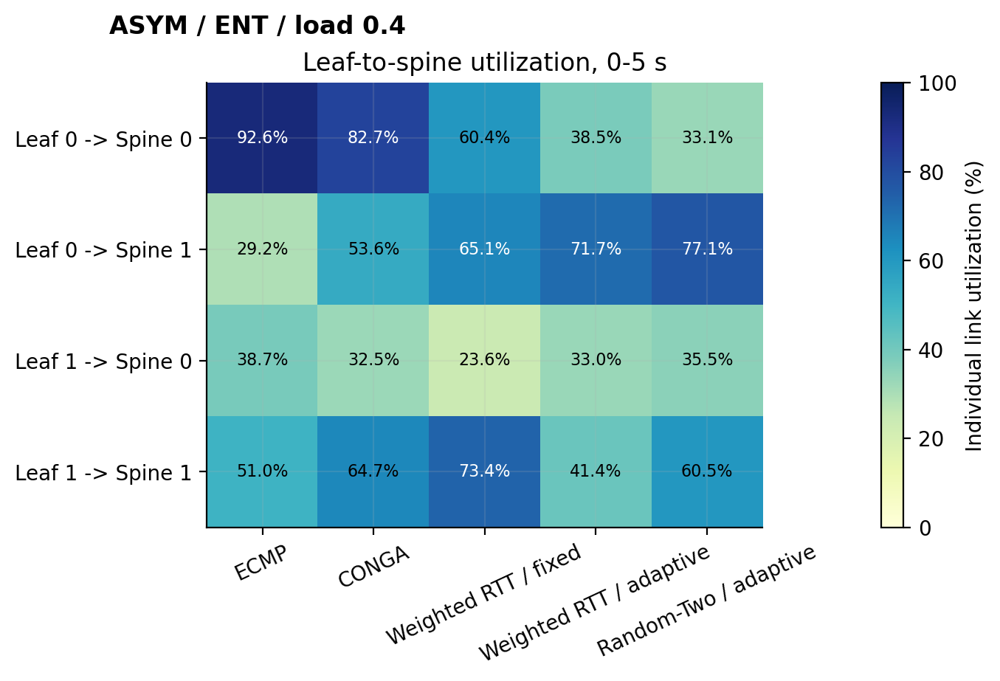

### ASYM / target load 0.5: Per-load FCT distribution

Within each size class, the vertical value is the fraction of verified completed flows with application FCT at or below the horizontal value. The horizontal scale is logarithmic; a curve further left reaches a given completion fraction sooner. Step shapes, especially for a small large-flow population, are expected. Each panel gives its number of flows per policy; no sizes are pooled across classes.

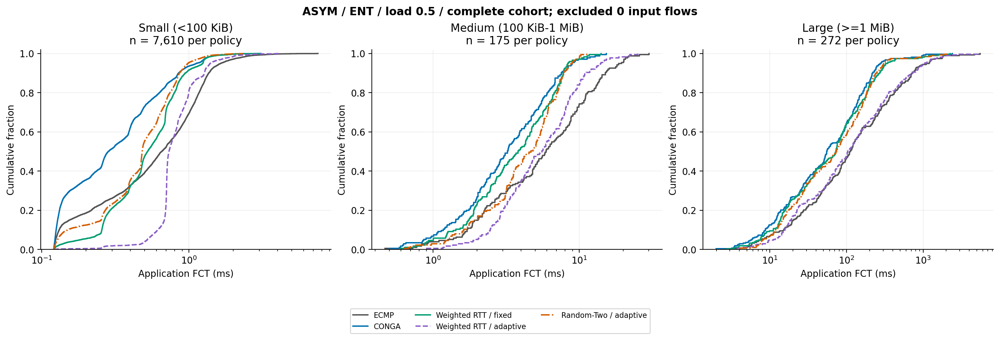

### ASYM / target load 0.5: Per-load FCT tail

The complementary CDF shows the fraction with application FCT strictly greater than the horizontal value, using logarithmic axes. At a fixed threshold, lower means fewer flows exceed it. The dotted 0.01 reference marks a one-percent tail. Ties are counted together and the zero-probability endpoint is omitted; a curve ending before another is not an incomplete transfer. Sample counts are shown, and the ordinary CDF remains available alongside this view.

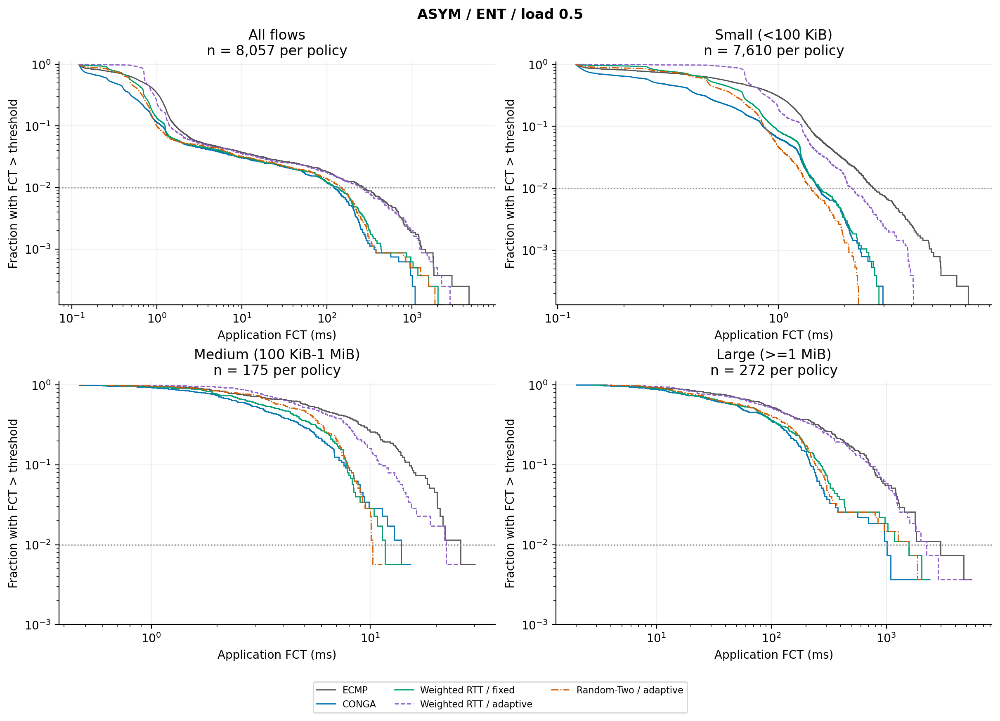

### ASYM / target load 0.5: Per-load directed uplink utilization

Each cell is bytes transmitted on that leaf-to-spine link during 0–5 s, divided by that individual link's capacity over five seconds. Cells are not shares of a single total and do not sum to 100%. The reduced Leaf 0–Spine 0 link uses 5 Gb/s for asymmetric runs. Other links use 10 Gb/s. The same color scale is used across all exported heatmaps. Traffic during drain is excluded; these averages do not reveal instantaneous queueing or prove packet reordering.

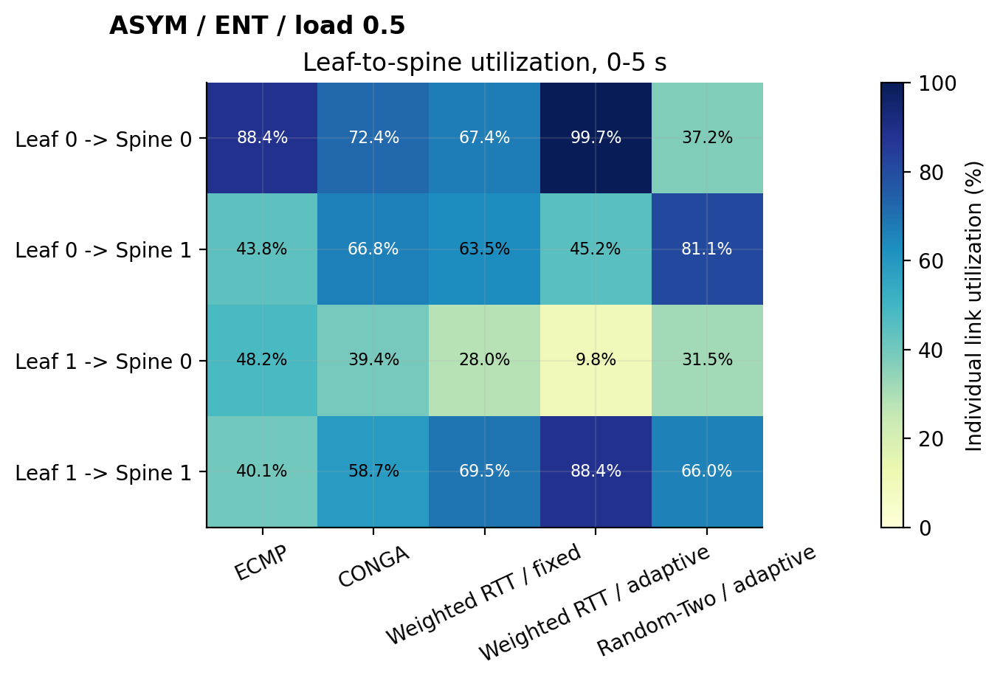

### ASYM / target load 0.6: Per-load FCT distribution

Within each size class, the vertical value is the fraction of verified completed flows with application FCT at or below the horizontal value. The horizontal scale is logarithmic; a curve further left reaches a given completion fraction sooner. Step shapes, especially for a small large-flow population, are expected. Each panel gives its number of flows per policy; no sizes are pooled across classes.

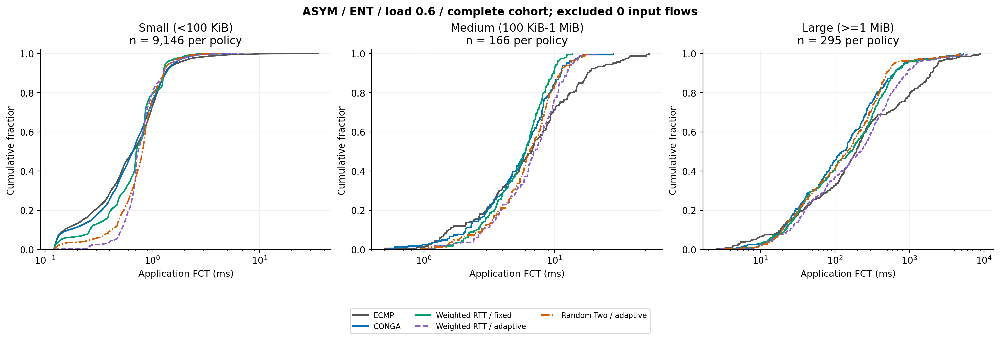

### ASYM / target load 0.6: Per-load FCT tail

The complementary CDF shows the fraction with application FCT strictly greater than the horizontal value, using logarithmic axes. At a fixed threshold, lower means fewer flows exceed it. The dotted 0.01 reference marks a one-percent tail. Ties are counted together and the zero-probability endpoint is omitted; a curve ending before another is not an incomplete transfer. Sample counts are shown, and the ordinary CDF remains available alongside this view.

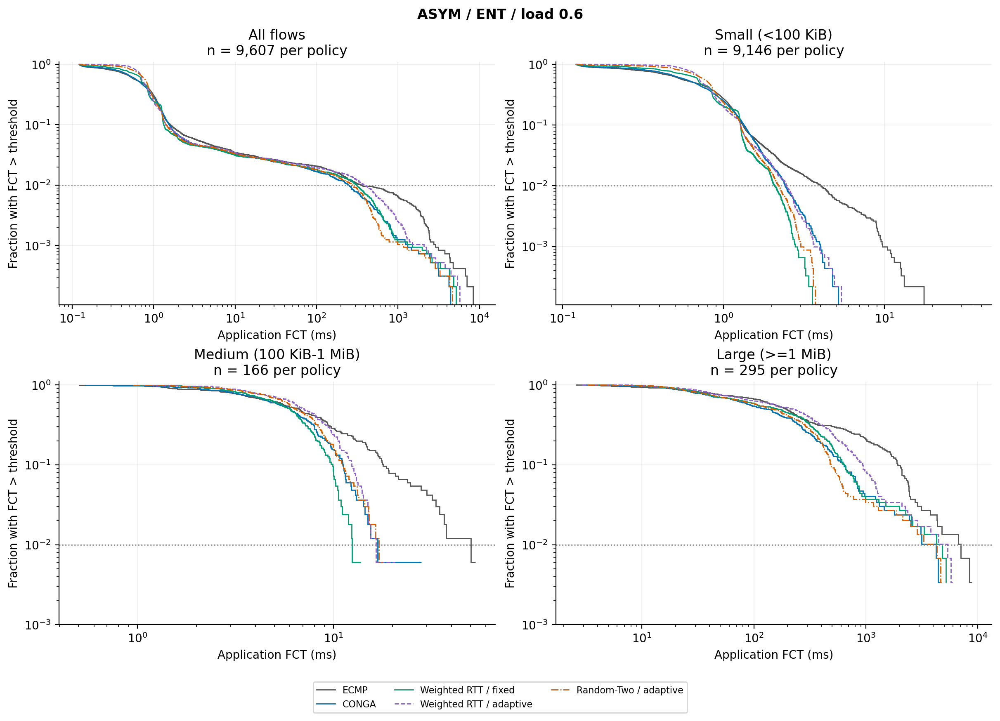

### ASYM / target load 0.6: Per-load directed uplink utilization

Each cell is bytes transmitted on that leaf-to-spine link during 0–5 s, divided by that individual link's capacity over five seconds. Cells are not shares of a single total and do not sum to 100%. The reduced Leaf 0–Spine 0 link uses 5 Gb/s for asymmetric runs. Other links use 10 Gb/s. The same color scale is used across all exported heatmaps. Traffic during drain is excluded; these averages do not reveal instantaneous queueing or prove packet reordering.

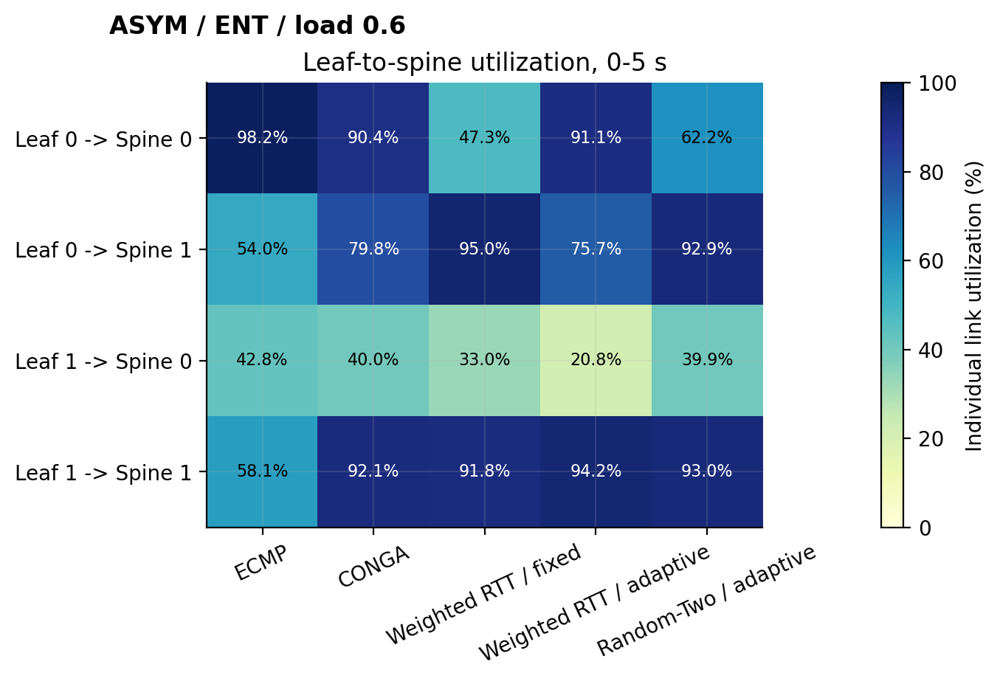

### ASYM / target load 0.7: Per-load FCT distribution

Within each size class, the vertical value is the fraction of verified completed flows with application FCT at or below the horizontal value. The horizontal scale is logarithmic; a curve further left reaches a given completion fraction sooner. Step shapes, especially for a small large-flow population, are expected. Each panel gives its number of flows per policy; no sizes are pooled across classes.

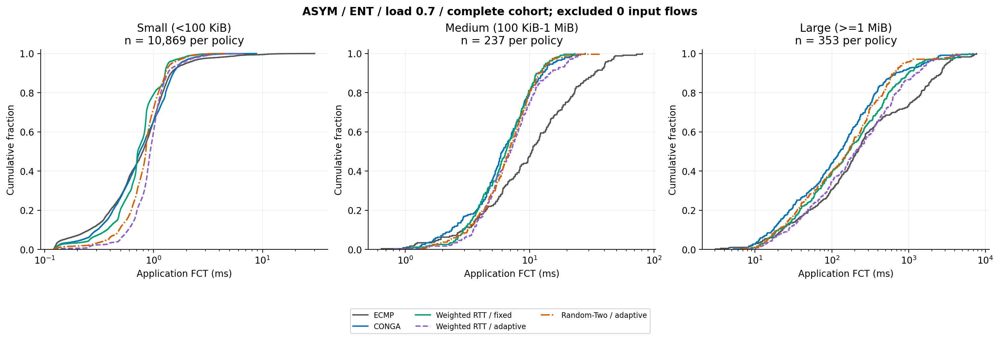

### ASYM / target load 0.7: Per-load FCT tail

The complementary CDF shows the fraction with application FCT strictly greater than the horizontal value, using logarithmic axes. At a fixed threshold, lower means fewer flows exceed it. The dotted 0.01 reference marks a one-percent tail. Ties are counted together and the zero-probability endpoint is omitted; a curve ending before another is not an incomplete transfer. Sample counts are shown, and the ordinary CDF remains available alongside this view.

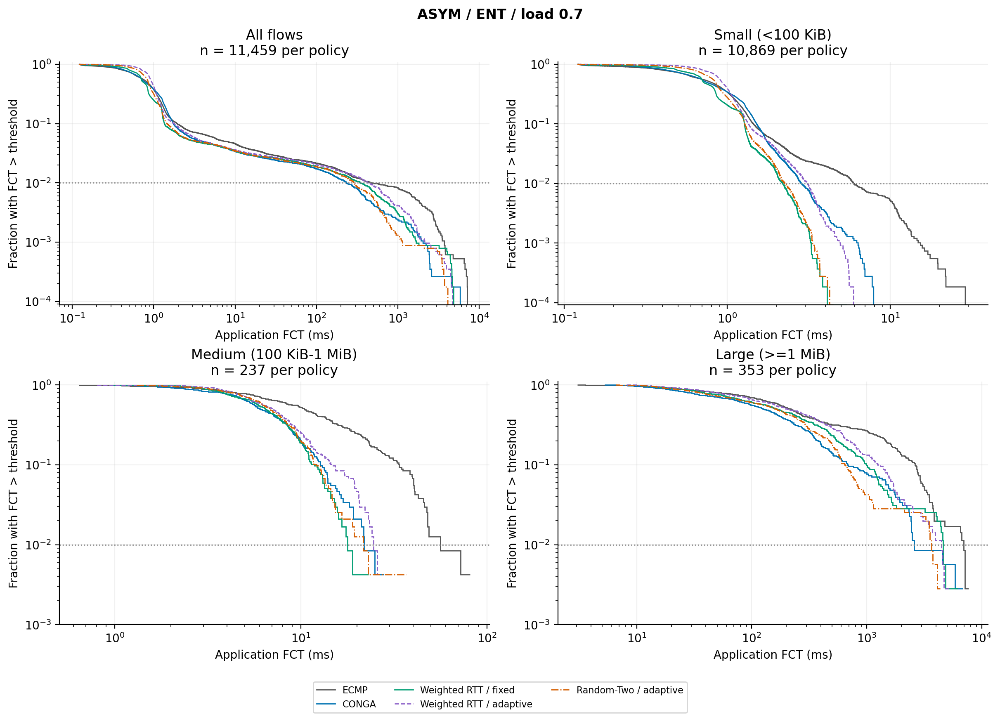

### ASYM / target load 0.7: Per-load directed uplink utilization

Each cell is bytes transmitted on that leaf-to-spine link during 0–5 s, divided by that individual link's capacity over five seconds. Cells are not shares of a single total and do not sum to 100%. The reduced Leaf 0–Spine 0 link uses 5 Gb/s for asymmetric runs. Other links use 10 Gb/s. The same color scale is used across all exported heatmaps. Traffic during drain is excluded; these averages do not reveal instantaneous queueing or prove packet reordering.

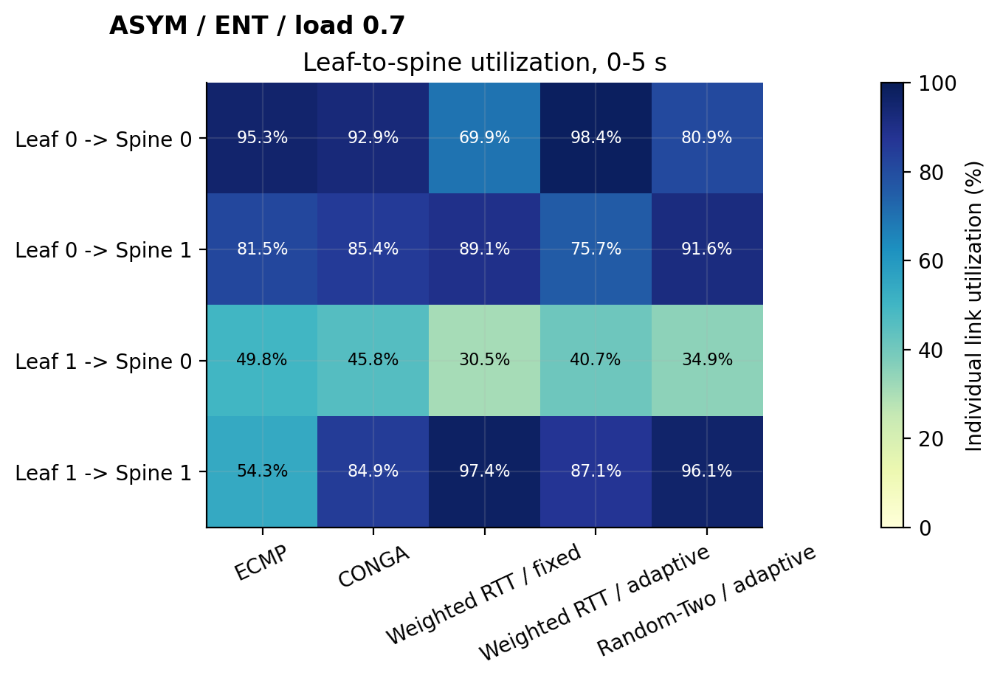

In [7]:
if "asym" in SCENARIOS:
    show_loads("asym")


## Numerical results and diagnostic files

The export retains the values behind the figures:

| File | What it contains |
| --- | --- |
| fct_summary.csv | Mean, p99, baseline ratios, and sample count for each topology, load, policy, and size class |
| run_summary.csv | Requested and verified flows, byte deficits, forward packet loss, and queue drops |
| cohorts.csv | Exact flow population used at each load, including excluded-flow counts |
| workload_summary.csv | Flow counts, bytes, realized load, traffic seeds, and trace checksums |
| input_manifests.csv | Generator settings copied from the trace manifests |
| issues.csv | Findings with a category, topology, load, policy, and trace index where applicable |
| Per-flow validation tables | Available in the full simulator export; omitted here to keep this showcase repository small |
| sym/summary/flow_issues.csv; asym/summary/flow_issues.csv | Flow records with validation findings |
| sym/summary/root_queue_disc_drops.csv; asym/summary/root_queue_disc_drops.csv | Root queue counters by interface and drop stage |
| sym/summary/root_drop_reasons.csv; asym/summary/root_drop_reasons.csv | Reported queue-drop reasons |
| sym/summary/device_queue_drops.csv; asym/summary/device_queue_drops.csv | Device-queue counters |
| sym/summary/uplink_utilization.csv; asym/summary/uplink_utilization.csv | Recorded bytes, physical capacities, and reported/recalculated utilization |
| source_files.csv; configuration.json | Input/output provenance and declared analysis settings |
| INDEX.md; figure_manifest.json | Complete figure index, captions, checksums, and suggested README subset |

The table below gives the overall FCT values. Per-size values and p99 ratios are
available in the exported summary. No composite score is assigned to algorithms:
mean latency, tail latency, losses, and link use answer different questions.


In [8]:
overall = [
    dict(topology=r["scenario"], load=int(r["load"]) / 10,
         policy=configuration["policies"][r["algorithm"]]["label"],
         flows=int(r["n"]), mean_ms=float(r["mean_fct_ms"]), p99_ms=float(r["p99_fct_ms"]),
         mean_over_ECMP=float(r["mean_relative_to_ecmp"]),
         mean_over_CONGA=float(r["mean_relative_to_conga"]))
    for r in metrics if r["size_group"] == "All flows"
]
show_table(overall, ["topology", "load", "policy", "flows", "mean_ms", "p99_ms",
                     "mean_over_ECMP", "mean_over_CONGA"])

# Fail visibly if the export format grows but this report omits a figure.
remaining = [r for r in FIGURES if r["png"] not in DISPLAYED]
if remaining:
    display(Markdown("## Additional exported figures"))
    for item in remaining:
        show_figure(item)
print(f"Displayed all {len(DISPLAYED)} figures from export {manifest['run_label_utc']}.")


topology,load,policy,flows,mean_ms,p99_ms,mean_over_ECMP,mean_over_CONGA
sym,0.1,ECMP,1678,1.9919,40.524,1,1.0791
sym,0.1,CONGA,1678,1.846,39.575,0.92674,1
sym,0.1,Weighted RTT / fixed,1678,1.977,46.769,0.99251,1.071
sym,0.1,Weighted RTT / adaptive,1678,2.1228,48.657,1.0657,1.15
sym,0.1,Random-Two / adaptive,1678,2.0274,46.772,1.0178,1.0983
sym,0.2,ECMP,3211,1.4496,44.627,1,1.0766
sym,0.2,CONGA,3211,1.3465,42.088,0.92884,1
sym,0.2,Weighted RTT / fixed,3211,1.416,44.668,0.97679,1.0516
sym,0.2,Weighted RTT / adaptive,3211,1.4909,52.611,1.0285,1.1072
sym,0.2,Random-Two / adaptive,3211,1.3918,40.878,0.96012,1.0337


Displayed all 65 figures from export 20261008T074640_547349Z.


## Scope of the conclusions

These figures establish what happened in the selected two-path, five-second
experiments. They do not reproduce the full-scale CONGA paper evaluation or
establish performance on other topologies. Longer observation windows, multiple
traffic and routing seeds, and more candidate paths are the next steps for
checking how consistently the observed behavior carries over.

For any reported gain, name the workload, topology, load, size class, metric,
and reference policy. Keep the delivery checks and sample counts with the result.
